# 1. Khám phá dữ liệu — EDA

## Giới thiệu

### Bối cảnh bài toán
Hệ thống chia sẻ xe đạp (bike sharing) cho phép người dùng thuê xe ở một trạm và trả ở trạm khác. Nhu cầu thuê xe thay đổi theo nhiều yếu tố: giờ trong ngày, ngày làm việc hay ngày nghỉ, mùa, và điều kiện thời tiết. Việc hiểu các yếu tố này giúp nhà vận hành điều phối xe, lên kế hoạch bảo trì và dự báo nhu cầu.

Notebook này thực hiện bước **khám phá dữ liệu (Exploratory Data Analysis – EDA)** trên bộ dữ liệu **Bike Sharing** để nắm rõ đặc điểm dữ liệu trước khi xây dựng mô hình dự báo.

### Nguồn dữ liệu
- **Bộ dữ liệu:** *Bike Sharing Dataset* trên UCI Machine Learning Repository (Fanaee-T & Gama, 2013).
- **Nguồn gốc:** dữ liệu vận hành của hệ thống **Capital Bikeshare** tại Washington D.C. (Hoa Kỳ), được tác giả ghép thêm thông tin thời tiết và lịch ngày lễ.
- **File sử dụng:** `hour.csv` — mỗi dòng ứng với **một giờ**.
- **Phạm vi thời gian:** từ 2011-01-01 đến 2012-12-31 (731 ngày, tương ứng tối đa 17 544 giờ).
- **Quy mô:** 17 379 bản ghi × 17 biến.

### Biến mục tiêu
**`cnt`** là tổng số lượt thuê xe trong một giờ, gồm hai thành phần: `casual` (khách vãng lai) và `registered` (thành viên đăng ký), với `cnt = casual + registered`. Vì vậy `casual` và `registered` không phải biến giải thích độc lập khi dự đoán `cnt`.

### Các nhóm biến
| Nhóm | Biến | Vai trò |
|---|---|---|
| Thời gian / lịch | `dteday`, `yr`, `mnth`, `hr`, `weekday` | Mô tả thời điểm, chu kỳ và xu hướng |
| Ngày đặc biệt | `holiday`, `workingday` | Phân biệt ngày làm việc, ngày nghỉ, ngày lễ |
| Mùa và thời tiết | `season`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed` | Điều kiện bên ngoài ảnh hưởng đến nhu cầu |
| Kết quả | `casual`, `registered`, `cnt` | Số lượt thuê |
| Định danh | `instant` | Số thứ tự bản ghi |

Lưu ý: các biến `temp`, `atemp`, `hum`, `windspeed` trong file gốc đã được **chuẩn hóa về thang 0–1** (`temp` và `atemp` theo min-max với cận −8/+39 °C và −16/+50 °C; `hum` chia 100; `windspeed` chia 67). Toàn bộ báo cáo **giữ giá trị chuẩn hóa**, không quy đổi về đơn vị gốc (chi tiết ở mục 1.1).

### Mục tiêu của EDA
1. Hiểu cấu trúc, kiểu dữ liệu và ý nghĩa từng biến.
2. Kiểm tra chất lượng dữ liệu (thiếu, trùng, bất hợp lệ, tính đầy đủ của chuỗi thời gian) và quyết định cách xử lý **dựa trên kết quả kiểm tra**.
3. Mô tả phân phối của biến mục tiêu và các biến giải thích quan trọng.
4. Trả lời các câu hỏi chính:
   - `cnt` phân bố như thế nào?
   - Nhu cầu có xu hướng và tính mùa vụ theo thời gian không?
   - Thời tiết (nhiệt độ, độ ẩm, gió) liên quan thế nào đến nhu cầu thuê?
   - `hr`, `workingday`, `season`, `weathersit` làm nhu cầu khác nhau ra sao?
   - Có ngoại lai hoặc vấn đề dữ liệu nào cần lưu ý cho bước mô hình hóa?

### Quy trình thực hiện
| Mục | Nội dung |
|---|---|
| 1.1 | Tổng quan dữ liệu, kiểm tra chất lượng, tiền xử lý |
| 1.2 | Thống kê mô tả và trực quan hóa |
| 1.3 | Phát hiện và đánh giá ngoại lai |
| 1.4 | Nhận xét tổng quan và lưu ý cho các bước tiếp theo |

### Nguyên tắc làm việc
- **Kiểm tra trước, quyết định sau:** mọi phương pháp xử lý (missing, duplicate, ngoại lai) chỉ được chọn sau khi đã có bằng chứng từ dữ liệu.
- **Giữ nguyên dữ liệu gốc:** `df_raw` giữ bản gốc, `df` chỉ đổi kiểu `dteday` sang `datetime` và sửa giá trị `hum` lỗi, không thêm cột nào (vẫn 17 cột); các cột nhãn phục vụ biểu đồ nằm ở `df_eda`.
- **Mỗi biểu đồ có mục đích:** nêu rõ biểu đồ dùng để tìm hiểu điều gì và dữ liệu thực tế cho thấy điều gì.
- **Ngoại lai thống kê không đồng nghĩa với lỗi dữ liệu:** chỉ loại bỏ khi có bằng chứng đó là lỗi.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 11})

DATA_PATH = '../data/hour.csv'
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()  # df_raw giữ nguyên bản gốc để đối chiếu

## 1.1. Tổng quan dữ liệu

**Mục tiêu.** Xác định bộ dữ liệu gồm những gì (nguồn, quy mô, kiểu dữ liệu, ý nghĩa và vai trò của từng biến), kiểm tra chất lượng và quyết định cách tiền xử lý dựa trên kết quả kiểm tra.

**Bối cảnh.** Hệ thống chia sẻ xe đạp (bike sharing) cho phép thuê xe ở một trạm và trả ở trạm khác. Nhu cầu thuê thay đổi theo giờ trong ngày, loại ngày và thời tiết, nên hiểu các yếu tố này giúp điều phối xe và dự báo nhu cầu.

**Nguồn dữ liệu.**
- Bike Sharing Dataset trên UCI Machine Learning Repository (Fanaee-T & Gama, 2013), bản đăng trên Kaggle.
- Dữ liệu vận hành của hệ thống Capital Bikeshare tại Washington D.C. (Hoa Kỳ), ghép thêm thông tin thời tiết và lịch ngày lễ.
- File `hour.csv`: mỗi dòng là một giờ, từ 2011-01-01 đến 2012-12-31 (731 ngày, tối đa 17,544 giờ).

**Biến mục tiêu.** Tổng số lượt thuê (`cnt`) trong một giờ, gồm lượt thuê của khách vãng lai (`casual`) và của thành viên đăng ký (`registered`), với `cnt = casual + registered`. Vì vậy `casual` và `registered` không được dùng làm biến độc lập khi dự đoán `cnt`, nếu dùng sẽ gây rò rỉ dữ liệu (data leakage); hai biến này chỉ dùng để mô tả.

**Phương pháp.** Kiểm tra cấu trúc bằng `info()` và `head()`, lập từ điển biến (Bảng 1.1), sau đó thực hiện bốn nhóm kiểm tra chất lượng (mục 1.1.1) và tiền xử lý theo kết quả (mục 1.1.2).

In [31]:
print(f"Số lượng bản ghi : {df.shape[0]:,}")
print(f"Số lượng biến    : {df.shape[1]}")
print(f"Khoảng thời gian : {df.dteday.min()} → {df.dteday.max()}")
print(f"Bộ nhớ           : {df.memory_usage(deep=True).sum()/1024:.0f} KB\n")
df.info()

Số lượng bản ghi : 17,379
Số lượng biến    : 17
Khoảng thời gian : 2011-01-01 → 2012-12-31
Bộ nhớ           : 3310 KB

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtyp

In [32]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Ý nghĩa các biến và phân loại

**Mục tiêu.** Nắm ý nghĩa, kiểu dữ liệu và loại của từng biến để chọn thống kê, biểu đồ và cách mã hóa phù hợp ở các bước sau.

**Chuẩn hóa của các biến thời tiết.** Theo tài liệu của bộ dữ liệu, bốn biến thời tiết trong `hour.csv` đã được đưa về thang 0–1. Với nhiệt độ, công thức min-max là

`x_chuẩn hóa = (x − x_min) / (x_max − x_min)`

trong đó `x` là nhiệt độ gốc (°C), `x_min` và `x_max` là hai cận cố định: `temp` dùng −8 và +39, `atemp` dùng −16 và +50. `hum` được chia cho 100 và `windspeed` được chia cho 67 (tài liệu không nêu đơn vị của tốc độ gió).

**Quyết định về thang đo.** Toàn bộ báo cáo giữ **giá trị chuẩn hóa** của bốn biến này và không quy đổi về đơn vị gốc. Mỗi khi nêu số liệu đều ghi rõ đây là giá trị chuẩn hóa (ví dụ `windspeed = 0.21` là giá trị chuẩn hóa).

**Bảng 1.1. Mô tả, kiểu dữ liệu và phân loại các biến của `hour.csv`**

In [33]:
data_dict = pd.DataFrame([
    ("instant",    "Chỉ số bản ghi (ID tăng dần)",                       "Identifier"),
    ("dteday",     "Ngày (YYYY-MM-DD)",                                   "Date/Time"),
    ("season",     "Mùa: 1 đông, 2 xuân, 3 hè, 4 thu",                    "Categorical (nominal)"),
    ("yr",         "Năm: 0 = 2011, 1 = 2012",                             "Categorical (binary)"),
    ("mnth",       "Tháng 1–12",                                          "Categorical (ordinal) / Date/Time"),
    ("hr",         "Giờ trong ngày 0–23",                                 "Categorical (ordinal) / Date/Time"),
    ("holiday",    "Ngày lễ (1) hay không (0)",                           "Categorical (binary)"),
    ("weekday",    "Thứ trong tuần 0–6 (0 = Chủ nhật)",                   "Categorical (ordinal) / Date/Time"),
    ("workingday", "Ngày làm việc (1): không phải cuối tuần, không lễ",   "Categorical (binary)"),
    ("weathersit", "Thời tiết: 1 quang, 2 mây/sương, 3 mưa/tuyết nhẹ, 4 mưa lớn", "Categorical (ordinal)"),
    ("temp",       "Nhiệt độ (chuẩn hóa, −8 đến +39 °C)",                        "Numerical (continuous)"),
    ("atemp",      "Nhiệt độ cảm nhận (chuẩn hóa, −16 đến +50 °C)",               "Numerical (continuous)"),
    ("hum",        "Độ ẩm (chuẩn hóa, /100)",                             "Numerical (continuous)"),
    ("windspeed",  "Tốc độ gió (chuẩn hóa, /67)",                         "Numerical (continuous)"),
    ("casual",     "Lượt thuê của khách vãng lai (không đăng ký)",        "Numerical (discrete, count)"),
    ("registered", "Lượt thuê của thành viên đã đăng ký",                 "Numerical (discrete, count)"),
    ("cnt",        "Tổng lượt thuê = casual + registered  (BIẾN MỤC TIÊU)", "Numerical (discrete, count)"),
], columns=["Biến", "Ý nghĩa", "Phân loại"])
data_dict["Kiểu dtype"] = data_dict["Biến"].map(df.dtypes.astype(str))
data_dict["Số giá trị khác nhau"] = data_dict["Biến"].map(df.nunique())
data_dict

,Biến,Ý nghĩa,Phân loại,Kiểu dtype,Số giá trị khác nhau
0,instant,Chỉ số bản ghi (ID tăng dần),Identifier,int64,17379
1,dteday,Ngày (YYYY-MM-DD),Date/Time,str,731
2,season,"Mùa: 1 đông, 2 xuân, 3 hè, 4 thu",Categorical (nominal),int64,4
3,yr,"Năm: 0 = 2011, 1 = 2012",Categorical (binary),int64,2
4,mnth,Tháng 1–12,Categorical (ordinal) / Date/Time,int64,12
5,hr,Giờ trong ngày 0–23,Categorical (ordinal) / Date/Time,int64,24
6,holiday,Ngày lễ (1) hay không (0),Categorical (binary),int64,2
7,weekday,Thứ trong tuần 0–6 (0 = Chủ nhật),Categorical (ordinal) / Date/Time,int64,7
8,workingday,"Ngày làm việc (1): không phải cuối tuần, không lễ",Categorical (binary),int64,2
9,weathersit,"Thời tiết: 1 quang, 2 mây/sương, 3 mưa/tuyết n...",Categorical (ordinal),int64,4


**Nhận xét Bảng 1.1.** Bộ dữ liệu có 17 biến, gồm 1 biến định danh (`instant`), 1 biến ngày (`dteday`, hiện đang là chuỗi), 8 biến phân loại mã hóa bằng số nguyên, 4 biến thời tiết liên tục đã chuẩn hóa và 3 biến đếm (`casual`, `registered`, `cnt`). Các biến phân loại chỉ có từ 2 đến 24 giá trị khác nhau (`yr`, `holiday`, `workingday`: 2; `season`, `weathersit`: 4; `weekday`: 7; `mnth`: 12; `hr`: 24), nên cần xử lý như biến phân loại hoặc biến chu kỳ thay vì biến liên tục. `dteday` có 731 giá trị khác nhau, khớp với 731 ngày của giai đoạn 2011–2012. Đáng chú ý, `windspeed` chỉ nhận 30 giá trị khác nhau trên 17,379 dòng, tức là biến này rời rạc theo từng mức.

#### Vì sao bộ dữ liệu được chuẩn hóa các biến thời tiết?
Tài liệu gốc chỉ mô tả *cách* chuẩn hóa, không giải thích *lý do*. Các ý dưới đây là suy luận, không phải phát biểu của tác giả.

1. **Đưa các biến về cùng thang đo.** Nhiệt độ, độ ẩm và tốc độ gió có thang đo rất khác nhau; sau chuẩn hóa cả bốn biến cùng nằm trong [0, 1], thuận lợi cho các thuật toán nhạy với thang đo như kNN, SVM, mạng nơ-ron và hồi quy có regularization.
2. **Không phụ thuộc đơn vị đo.** Dữ liệu thời tiết ở Mỹ thường dùng °F và mph; thang 0–1 cho phép dùng dữ liệu mà không cần quan tâm đơn vị gốc.
3. **Phép biến đổi tuyến tính nên không mất thông tin.** Hình dạng phân phối, thứ hạng và hệ số tương quan (Pearson, Spearman) không đổi, nên kết luận EDA không phụ thuộc việc dùng giá trị chuẩn hóa hay giá trị gốc.
4. **Cận cố định, không fit trên dữ liệu.** `x_min` và `x_max` là hằng số cho trước nên không có nguy cơ rò rỉ thông tin giữa tập huấn luyện và tập kiểm tra, khác với việc fit bộ chuẩn hóa trên toàn bộ dữ liệu.
5. **Cận gần khớp phạm vi quan sát.** `temp` có min = 0.02 và max = 1.00, `atemp` có min = 0.00 và max = 1.00, trong khi `windspeed` lớn nhất là 0.85, tức cận 67 chỉ là cận tham chiếu.

#### Hệ quả khi phân tích
- Hệ số hồi quy của `temp`, `atemp`, `hum`, `windspeed` ở thang 0–1 là mức thay đổi của `cnt` khi biến đi hết toàn bộ khoảng từ nhỏ nhất đến lớn nhất, nên cần diễn giải theo ý nghĩa đó.
- Mô hình cây không cần chuẩn hóa thêm. Mô hình tuyến tính, kNN và mạng nơ-ron có thể cần `StandardScaler`, fit **chỉ trên tập huấn luyện**.
- `temp` và `atemp` có tương quan rất cao (0.9877, xem mục 1.1.1c) nên chỉ nên giữ một biến trong mô hình tuyến tính.
- Báo cáo không tạo thêm cột quy đổi đơn vị; các biểu đồ và thống kê ở mục 1.2 và 1.3 dùng trực tiếp giá trị chuẩn hóa.

### Phân loại các biến theo kiểu dữ liệu

In [34]:
NUM_CONT = ["temp", "atemp", "hum", "windspeed"]
NUM_COUNT = ["casual", "registered", "cnt"]
CATEGORICAL = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]
DATETIME = ["dteday"]
TARGET = "cnt"
print("Numerical  :", NUM_CONT + NUM_COUNT)
print("Categorical:", CATEGORICAL)
print("Date/Time  :", DATETIME, "(+ yr, mnth, hr, weekday là các thành phần thời gian)")

Numerical  : ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
Categorical: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
Date/Time  : ['dteday'] (+ yr, mnth, hr, weekday là các thành phần thời gian)


Cách phân loại biến quyết định thống kê, biểu đồ và cách mã hóa nào là phù hợp: một biến lưu bằng số nguyên chưa chắc là biến số theo nghĩa phân tích.

- **Numerical liên tục** (`temp`, `atemp`, `hum`, `windspeed`): tính được mean, std và tương quan, vẽ được histogram và scatter. Giá trị chuẩn hóa vẫn giữ thứ tự và khoảng cách giữa các quan sát.
- **Numerical đếm** (`casual`, `registered`, `cnt`): số nguyên không âm, thường lệch phải và có phương sai lớn hơn trung bình, nên không mặc định giả định phân phối chuẩn (kiểm tra ở mục 1.2).
- **Categorical nhị phân** (`yr`, `holiday`, `workingday`): chỉ có hai trạng thái 0/1, phù hợp để so sánh trung bình giữa hai nhóm.
- **Categorical định danh** (`season`): bốn nhóm; mã 1 → 4 không có khoảng cách đều nhau.
- **Categorical có thứ tự** (`weathersit`): mã tăng dần theo mức thời tiết xấu nhưng khoảng cách giữa các mức không đều; mức 4 chỉ có 3 dòng (mục 1.1.1c).
- **Thành phần thời gian có chu kỳ** (`mnth`, `weekday`, `hr`): lưu bằng số nhưng tuần hoàn (giờ 23 liền kề giờ 0, tháng 12 liền kề tháng 1), nên không coi là biến liên tục thuần; khi mô hình hóa cần one-hot hoặc mã hóa sin/cos.
- **Date/Time** (`dteday`): đang là chuỗi, được chuyển sang `datetime` ở mục 1.1.2.
- **Định danh** (`instant`): chỉ là số thứ tự bản ghi, không đưa vào phân tích hay mô hình (vì vậy không có trong danh sách ở cell trên).

Hai điểm cần lưu ý. Thứ nhất, `hr`, `mnth`, `weekday` nằm ở ranh giới giữa Categorical và Date/Time; trong notebook chúng được xếp vào Categorical để thống kê theo nhóm và vẫn được hiểu là thành phần thời gian khi phân tích xu hướng và mùa vụ. Thứ hai, `cnt` đồng thời là tổng của hai biến số khác, nên `TARGET` được tách riêng khỏi các nhóm biến giải thích.

**Nhận xét ban đầu về dữ liệu.** Bộ dữ liệu có 17,379 dòng và 17 cột (12 cột `int64`, 4 cột `float64` và 1 cột chuỗi `dteday`), mỗi dòng là một giờ trong giai đoạn 2011–2012. Số giờ lý thuyết của 731 ngày là 17,544, lớn hơn số dòng hiện có, nên chuỗi thời gian có thể chưa liên tục (kiểm tra ở mục 1.1.1d). `info()` không báo ô trống nào, nhưng điều này chưa đủ để kết luận dữ liệu không có giá trị thiếu, vì giá trị thiếu đôi khi được mã hóa thành một con số cụ thể.

Các biến giải thích gồm nhóm thời gian (`yr`, `mnth`, `hr`, `weekday`, `holiday`, `workingday`) và nhóm thời tiết (`season`, `weathersit`, `temp`, `atemp`, `hum`, `windspeed`). Giữa chúng có quan hệ dẫn xuất hoặc trùng thông tin, chẳng hạn `workingday` suy ra từ `weekday` và `holiday`, còn `temp` và `atemp` cùng đo nhiệt độ. Về kiểu dữ liệu, `dteday` là chuỗi nên cần chuyển sang `datetime`; các biến phân loại là số nguyên nên không nên xử lý như biến liên tục, đặc biệt `hr`, `mnth`, `weekday` có tính chu kỳ; bốn biến thời tiết được giữ ở thang chuẩn hóa 0–1. Các điểm nghi vấn trên, cùng tính nhất quán giữa các biến, được kiểm tra ở mục 1.1.1 trước khi quyết định cách xử lý.

### 1.1.1. Kiểm tra chất lượng dữ liệu

**Mục tiêu.** Phát hiện các vấn đề về chất lượng dữ liệu trước khi phân tích. Ở bước này chỉ **kiểm tra và ghi nhận**; quyết định xử lý đưa ra ở mục 1.1.2 dựa trên kết quả.

**Phương pháp.** Bốn nhóm kiểm tra: (a) giá trị thiếu và bản ghi trùng lặp; (b) giá trị bất hợp lệ (miền giá trị và ràng buộc logic giữa các biến); (c) giá trị nằm trong miền hợp lệ nhưng đáng ngờ; (d) tính đầy đủ của chuỗi thời gian.

**a) Giá trị thiếu và bản ghi trùng lặp**

Giá trị thiếu làm giảm số quan sát dùng được, còn bản ghi trùng lặp khiến một số quan sát bị đếm nhiều lần, làm lệch trung bình, phân phối và tương quan. Cell dưới đây kiểm tra bốn điều: (1) số ô thiếu và tỷ lệ thiếu của từng biến bằng `isna()`; (2) số dòng trùng lặp hoàn toàn trên cả 17 cột; (3) số dòng trùng theo cặp (`dteday`, `hr`), vì mỗi giờ của mỗi ngày chỉ được xuất hiện một lần và hai dòng có thể khác nhau ở vài cột nhưng vẫn là cùng một giờ; (4) cột `instant` có duy nhất và tăng dần hay không, để biết thứ tự bản ghi còn nguyên vẹn.

In [35]:
missing = df.isna().sum().to_frame("n_missing")
missing["pct"] = (missing.n_missing / len(df) * 100).round(2)
print("Tổng ô thiếu:", int(missing.n_missing.sum()))
print("Dòng trùng lặp hoàn toàn      :", df.duplicated().sum())
print("Trùng cặp (dteday, hr)        :", df.duplicated(["dteday", "hr"]).sum())
print("`instant` có duy nhất & tăng? :", df.instant.is_unique and df.instant.is_monotonic_increasing)
missing.T

Tổng ô thiếu: 0
Dòng trùng lặp hoàn toàn      : 0
Trùng cặp (dteday, hr)        : 0
`instant` có duy nhất & tăng? : True


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
n_missing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pct,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Nhận xét.** Dữ liệu **không có giá trị thiếu dạng ô trống** ở cả 17 biến (tổng ô thiếu bằng 0), không có dòng trùng lặp hoàn toàn và không có cặp (`dteday`, `hr`) nào bị lặp; `instant` duy nhất và tăng dần nên thứ tự bản ghi còn nguyên vẹn. Kết quả này chỉ áp dụng cho giá trị thiếu **ở dạng ô trống**. Giá trị thiếu vẫn có thể tồn tại dưới dạng **ẩn**, chẳng hạn được mã hóa thành một con số cụ thể như `0`, hoặc là cả dòng của một giờ không được ghi nhận; hai khả năng này được kiểm tra ở các mục b), c) và d). Vì chưa phát hiện vấn đề nào ở bước này, **không cần xử lý giá trị thiếu hay bản ghi trùng lặp**.

**b) Giá trị bất hợp lệ**

Một giá trị có thể không trống nhưng vẫn sai: nằm ngoài miền cho phép của biến hoặc mâu thuẫn với các biến khác. Cell dưới đây kiểm tra hai lớp.

**Lớp 1: miền giá trị của từng biến.** Mỗi biến được so với miền hợp lệ theo mô tả của bộ dữ liệu: biến phân loại nằm trong tập mã cho phép (ví dụ `season` từ 1 đến 4, `hr` từ 0 đến 23), biến thời tiết chuẩn hóa nằm trong [0, 1], biến đếm (`casual`, `registered`, `cnt`) không âm.

**Lớp 2: ràng buộc logic giữa các biến.** Nhiều biến được dẫn xuất từ nhau nên phải khớp nhau:
- `cnt` phải bằng `casual + registered`.
- `weekday`, `mnth`, `yr` phải khớp với ngày thực tế trong `dteday` (bộ dữ liệu mã hóa Sunday là 0 trong khi `pandas` mã hóa Monday là 0, nên quy đổi bằng `(dayofweek + 1) % 7`).
- `workingday` bằng 1 khi và chỉ khi ngày đó từ Monday đến Friday và không phải ngày lễ.
- `workingday` và `holiday` có cùng một giá trị trong mọi giờ của một ngày.
- `cnt` không nên bằng 0, vì nếu có thì cần phân biệt giờ không có lượt thuê với giờ không ghi nhận.

Cả hai lớp chỉ **đếm số dòng vi phạm**, chưa sửa gì.

In [36]:
dt_check = pd.to_datetime(df.dteday)

valid_ranges = {
    "season": (1, 4), "yr": (0, 1), "mnth": (1, 12), "hr": (0, 23), "holiday": (0, 1),
    "weekday": (0, 6), "workingday": (0, 1), "weathersit": (1, 4),
    "temp": (0, 1), "atemp": (0, 1), "hum": (0, 1), "windspeed": (0, 1),
    "casual": (0, np.inf), "registered": (0, np.inf), "cnt": (0, np.inf),
}
range_report = pd.DataFrame({
    "min": df[list(valid_ranges)].min(),
    "max": df[list(valid_ranges)].max(),
    "vi_pham": {c: int(((df[c] < lo) | (df[c] > hi)).sum()) for c, (lo, hi) in valid_ranges.items()},
})
display(range_report)

logic_checks = {
    "cnt != casual + registered":               int((df.cnt != df.casual + df.registered).sum()),
    "weekday không khớp với dteday":            int((((dt_check.dt.dayofweek + 1) % 7) != df.weekday).sum()),
    "mnth không khớp với dteday":               int((dt_check.dt.month != df.mnth).sum()),
    "yr không khớp với dteday":                 int(((dt_check.dt.year - 2011) != df.yr).sum()),
    "workingday mâu thuẫn (weekday, holiday)":  int((df.workingday != (df.weekday.between(1, 5) & (df.holiday == 0)).astype(int)).sum()),
    "Một ngày có >1 giá trị workingday/holiday": int((df.groupby("dteday")[["workingday", "holiday"]].nunique() > 1).any(axis=1).sum()),
    "cnt = 0":                                  int((df.cnt == 0).sum()),
}
pd.Series(logic_checks, name="so_dong_vi_pham").to_frame()

,min,max,vi_pham
season,1.00,4.0000,0
yr,0.00,1.0000,0
mnth,1.00,12.0000,0
hr,0.00,23.0000,0
holiday,0.00,1.0000,0
weekday,0.00,6.0000,0
workingday,0.00,1.0000,0
weathersit,1.00,4.0000,0
temp,0.02,1.0000,0
atemp,0.00,1.0000,0


,so_dong_vi_pham
cnt != casual + registered,0
weekday không khớp với dteday,0
mnth không khớp với dteday,0
yr không khớp với dteday,0
"workingday mâu thuẫn (weekday, holiday)",0
Một ngày có >1 giá trị workingday/holiday,0
cnt = 0,0


**Nhận xét.** Không có dòng nào vi phạm ở cả hai lớp. Mọi biến nằm trong miền hợp lệ: `temp` từ 0.02 đến 1.00, `atemp` từ 0.00 đến 1.00, `hum` từ 0.00 đến 1.00, `windspeed` từ 0.00 đến 0.8507; `cnt` từ 1 đến 977, `casual` từ 0 đến 367, `registered` từ 0 đến 886. Các ràng buộc logic đều thỏa: `cnt = casual + registered` đúng ở mọi dòng, `weekday`, `mnth`, `yr` khớp hoàn toàn với `dteday`, `workingday` nhất quán với `weekday` và `holiday`, và không có giờ nào có `cnt = 0`. Điều này cho thấy các biến lịch được sinh nhất quán, nên có thể dùng chúng để nhóm dữ liệu ở các bước sau.

Tuy nhiên, phép kiểm tra chỉ bắt được giá trị **ngoài miền**, không bắt được giá trị **nằm trong miền nhưng đáng ngờ**: `hum = 0` và `windspeed = 0` vẫn thuộc đoạn [0, 1] nên không bị đánh dấu, dù độ ẩm 0% là bất khả thi về mặt vật lý. Nhóm giá trị này được xem xét riêng ở mục c).

**c) Các giá trị đáng ngờ về mặt vật lý hoặc đo đạc**

Một số giá trị nằm trong miền hợp lệ nhưng vô lý về mặt vật lý hoặc đo đạc, và chỉ lộ ra khi đối chiếu với ý nghĩa của biến. Cell dưới đây xem xét bốn dấu hiệu:

- **`hum = 0`:** độ ẩm không khí 0% gần như không xảy ra trong khí quyển thực. Cần xem các dòng này rải rác hay dồn vào cùng một thời điểm.
- **`windspeed = 0`:** gió bằng đúng 0 là có thể xảy ra, nhưng nếu số dòng lớn và giá trị dương nhỏ nhất cách 0 một khoảng xa thì số 0 có thể là *không đo được* chứ không phải *không có gió*.
- **`weathersit = 4`:** nhóm thời tiết xấu nhất; cần đếm số quan sát để biết nhóm này có đủ lớn cho thống kê theo nhóm không.
- **Tương quan giữa `temp` và `atemp`:** hai biến cùng đo nhiệt độ (thực tế và cảm nhận), cần định lượng mức trùng thông tin.

**Hình 1.1. Các giá trị đáng ngờ của `windspeed` và `hum`**

- **Mục đích:** quan sát khoảng trống sau giá trị 0 của `windspeed`, cụm giá trị 0 của `hum` và thời điểm xuất hiện cụm này.
- **Lý do lựa chọn:** biểu đồ cột của 10 giá trị `windspeed` nhỏ nhất trên trục số thật làm lộ khoảng trống mà histogram 40 khoảng khó hiện; histogram toàn bộ cho thấy quy mô cột 0 so với phân phối chung; biểu đồ đường `hum` trung bình theo ngày cho biết cụm 0 là rải rác hay dồn vào một ngày.

hum == 0       : 22 dòng, thuộc các ngày: ['2011-03-10']
windspeed == 0 : 2180 dòng (12.5%)
windspeed nhỏ nhất > 0: 0.0896 → ×67 = 6.0 (đơn vị gốc)
weathersit == 4: 3 dòng
corr(temp, atemp) = 0.988


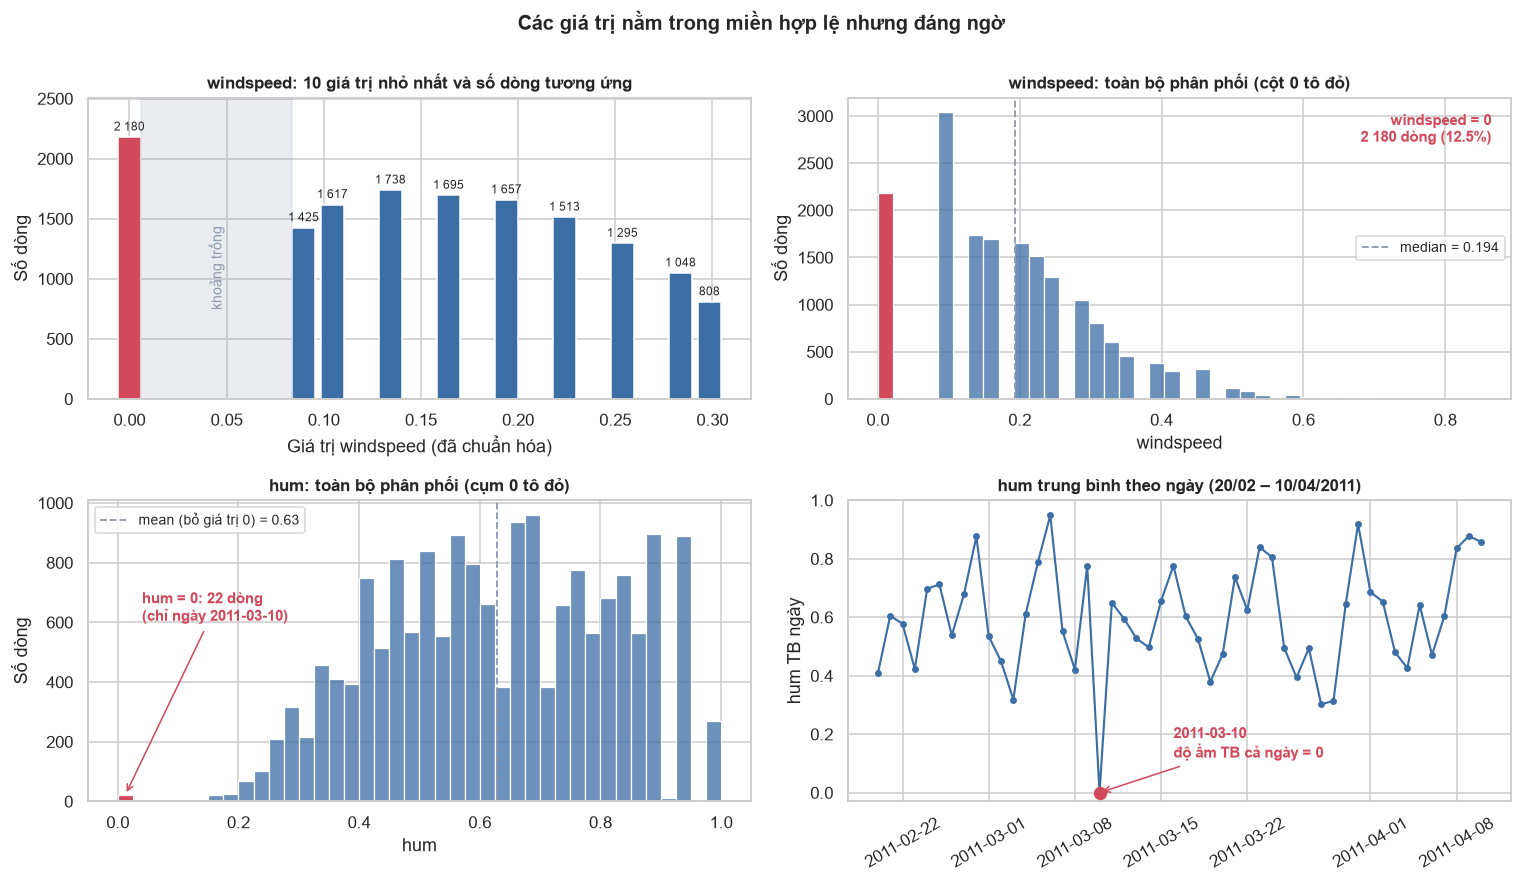

In [37]:
n_ws0, n_hum0 = (df.windspeed == 0).sum(), (df.hum == 0).sum()
ws_min_pos = df.loc[df.windspeed > 0, "windspeed"].min()
RED, BLUE, GREY = "#d1495b", "#3b6ea5", "#8d99ae"

print("hum == 0       :", n_hum0, "dòng, thuộc các ngày:", df.loc[df.hum == 0, "dteday"].unique().tolist())
print("windspeed == 0 :", n_ws0, "dòng (%.1f%%)" % ((df.windspeed == 0).mean() * 100))
print("windspeed nhỏ nhất > 0:", ws_min_pos, "→ ×67 =", round(ws_min_pos * 67, 1), "(đơn vị gốc)")
print("weathersit == 4:", (df.weathersit == 4).sum(), "dòng")
print("corr(temp, atemp) = %.3f" % df.temp.corr(df.atemp))

fig, ax = plt.subplots(2, 2, figsize=(14, 8))

# (1) windspeed: các giá trị nhỏ nhất trên trục số thật -> thấy rõ khoảng trống sau số 0
vc = df.windspeed.value_counts().sort_index().head(10)
ax[0, 0].bar(vc.index, vc.values, width=0.012, color=[RED] + [BLUE] * (len(vc) - 1))
ax[0, 0].axvspan(0.006, ws_min_pos - 0.006, color=GREY, alpha=0.18)
ax[0, 0].text((0.006 + ws_min_pos - 0.006) / 2, vc.values.max() * 0.5, "khoảng trống", rotation=90, ha="center", va="center", color=GREY, fontsize=9)
for x, v in zip(vc.index, vc.values):
    ax[0, 0].text(x, v + vc.values.max() * 0.015, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=8)
ax[0, 0].set_ylim(0, vc.values.max() * 1.15)
ax[0, 0].set_title("windspeed: 10 giá trị nhỏ nhất và số dòng tương ứng")
ax[0, 0].set_xlabel("Giá trị windspeed (đã chuẩn hóa)"); ax[0, 0].set_ylabel("Số dòng")

# (2) windspeed: toàn bộ phân phối, cột 0 tô đỏ
sns.histplot(df.windspeed, bins=np.linspace(0, df.windspeed.max(), 41), color=BLUE, ax=ax[0, 1])
ax[0, 1].patches[0].set_facecolor(RED)
ax[0, 1].text(0.97, 0.95, f"windspeed = 0\n{n_ws0:,} dòng ({n_ws0 / len(df):.1%})".replace(",", " "), transform=ax[0, 1].transAxes,
              ha="right", va="top", color=RED, fontsize=10, fontweight="bold")
ax[0, 1].axvline(df.windspeed.median(), color=GREY, ls="--", lw=1.2, label=f"median = {df.windspeed.median():.3f}")
ax[0, 1].legend(loc="center right", fontsize=9)
ax[0, 1].set_title("windspeed: toàn bộ phân phối (cột 0 tô đỏ)"); ax[0, 1].set_xlabel("windspeed"); ax[0, 1].set_ylabel("Số dòng")

# (3) hum: toàn bộ phân phối, cụm 0 tô đỏ
sns.histplot(df.hum, bins=np.linspace(0, 1, 41), color=BLUE, ax=ax[1, 0])
ax[1, 0].patches[0].set_facecolor(RED)
ax[1, 0].annotate(f"hum = 0: {n_hum0} dòng\n(chỉ ngày 2011-03-10)", xy=(0.0125, n_hum0), xytext=(0.04, ax[1, 0].get_ylim()[1] * 0.6),
                  color=RED, fontsize=10, fontweight="bold", arrowprops=dict(arrowstyle="->", color=RED))
ax[1, 0].axvline(df.loc[df.hum > 0, "hum"].mean(), color=GREY, ls="--", lw=1.2, label=f"mean (bỏ giá trị 0) = {df.loc[df.hum > 0, 'hum'].mean():.2f}")
ax[1, 0].legend(loc="upper left", fontsize=9)
ax[1, 0].set_title("hum: toàn bộ phân phối (cụm 0 tô đỏ)"); ax[1, 0].set_xlabel("hum"); ax[1, 0].set_ylabel("Số dòng")

# (4) hum theo thời gian quanh ngày bất thường
d = pd.to_datetime(df.dteday)
daily_hum = df.assign(d=d).groupby("d")["hum"].mean()
win = daily_hum["2011-02-20":"2011-04-10"]
ax[1, 1].plot(win.index, win.values, marker="o", ms=3.5, lw=1.4, color=BLUE)
bad = win[win == 0]
ax[1, 1].scatter(bad.index, bad.values, color=RED, s=60, zorder=3)
ax[1, 1].annotate("2011-03-10\nđộ ẩm TB cả ngày = 0", xy=(bad.index[0], 0), xytext=(bad.index[0] + pd.Timedelta(days=6), 0.12),
                  color=RED, fontsize=10, fontweight="bold", arrowprops=dict(arrowstyle="->", color=RED))
ax[1, 1].set_title("hum trung bình theo ngày (20/02 – 10/04/2011)"); ax[1, 1].set_ylabel("hum TB ngày"); ax[1, 1].set_ylim(-0.03, 1)
ax[1, 1].tick_params(axis="x", rotation=30)

plt.suptitle("Các giá trị nằm trong miền hợp lệ nhưng đáng ngờ", fontsize=13, fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

**Nhận xét Hình 1.1.**

- **`hum = 0`:** 22 dòng, **tất cả thuộc ngày 2011-03-10**, và ngày này cũng chỉ có đúng 22 dòng dữ liệu; biểu đồ đường cho thấy độ ẩm trung bình của cả ngày bằng 0 rồi trở lại mức bình thường vào ngày hôm sau. Độ ẩm 0% kéo dài cả ngày là bất khả thi trong khí quyển thực, nên nhiều khả năng đây là lỗi cảm biến hoặc lỗi ghi nhận, không phải hiện tượng thời tiết (suy luận từ dữ liệu, chưa được nguồn xác nhận).
- **`windspeed = 0`:** 2,180 dòng (12.54%). Sau giá trị 0, giá trị dương nhỏ nhất là 0.0896 (6.00 theo thang gốc ×67), tức không có quan sát nào ở giữa, và các giá trị còn lại cũng rời rạc theo từng mức. Có hai cách hiểu: gió thực sự bằng 0, hoặc gió dưới ngưỡng đo/không đo được và bị ghi là 0. Dữ liệu hiện có chưa đủ để phân biệt hai khả năng; phân bố của các giá trị 0 theo thời gian được khảo sát thêm ở mục 1.3.2.
- **`weathersit = 4`:** chỉ 3 dòng trên 17,379 dòng, quá ít để thống kê theo nhóm (trung bình, độ phân tán) có ý nghĩa.
- **`temp` và `atemp`:** tương quan Pearson 0.9877, tức gần như trùng thông tin; đưa cả hai vào mô hình tuyến tính sẽ gây đa cộng tuyến mà không thêm thông tin.

Cách xử lý `hum = 0` và `windspeed = 0` được quyết định ở mục 1.1.2; `weathersit = 4` và cặp `temp`–`atemp` được ghi nhận để lưu ý ở các mục sau.

**d) Tính đầy đủ của chuỗi thời gian**

Các mục a) đến c) kiểm tra những dòng **đang có**; mục này kiểm tra những dòng **đáng lẽ phải có nhưng không có**. Dữ liệu ghi nhận theo giờ trong 731 ngày, nên nếu đầy đủ sẽ có 731 × 24 = 17,544 dòng. Chuỗi bị đứt quãng làm tổng lượt thuê theo ngày thấp đi ở những ngày thiếu giờ, và làm lệch các đặc trưng trễ (lag) hoặc trung bình trượt nếu coi hai dòng liền kề là hai giờ liên tiếp.

Cell dưới đây ghép `dteday` và `hr` thành mốc thời gian đầy đủ, tạo dải thời gian lý tưởng từng giờ từ 2011-01-01 00:00 đến 2012-12-31 23:00, rồi lấy hiệu của hai tập để tìm các giờ vắng mặt. Cột `_ts` chỉ là cột tạm, được xóa ngay sau khi kiểm tra.

**Hình 1.2. Các giờ bị thiếu theo giờ trong ngày và theo ngày**

- **Mục đích:** xác định giờ thiếu tập trung ở khung giờ nào và ở những ngày nào, để phân biệt hai nguyên nhân khác nhau: thiếu do hệ thống chỉ ghi dòng khi có lượt thuê (thường rơi vào giờ đêm) và thiếu do sự cố hoặc điều kiện bất thường (thường dồn vào vài ngày).
- **Lý do lựa chọn:** biểu đồ cột đếm số giờ thiếu theo `hr`, kèm đường `cnt` trung bình theo giờ để đối chiếu với nhu cầu; biểu đồ cột ngang xếp hạng các ngày thiếu nhiều giờ nhất, tô màu theo mức độ vì số giờ thiếu là biến đếm có thứ bậc.

Số giờ kỳ vọng: 17,544 | thực có: 17,379 | thiếu: 165 (0.9%)
Thiếu trong khung 2–5h sáng: 98 / 165 (59.4%)


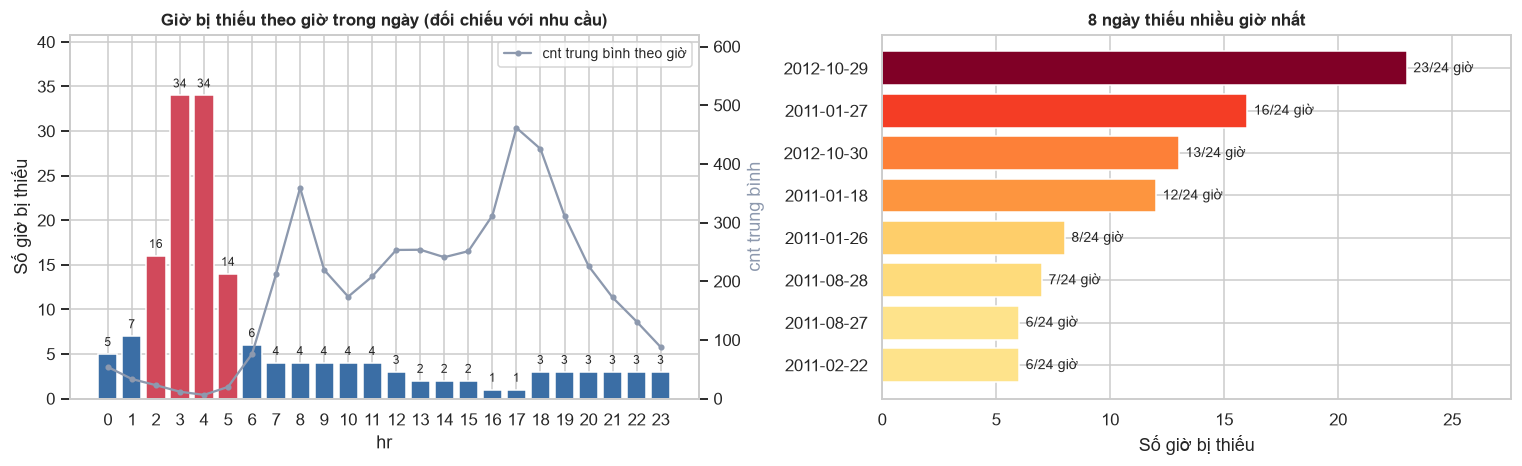

In [38]:
RED, BLUE, GREY, ORANGE = "#d1495b", "#3b6ea5", "#8d99ae", "#e08e45"

df["_ts"] = pd.to_datetime(df.dteday) + pd.to_timedelta(df.hr, unit="h")
full_range = pd.date_range("2011-01-01 00:00", "2012-12-31 23:00", freq="h")
missing_ts = full_range.difference(df["_ts"])
print(f"Số giờ kỳ vọng: {len(full_range):,} | thực có: {len(df):,} | thiếu: {len(missing_ts)} ({len(missing_ts)/len(full_range):.1%})")

miss_by_hr  = pd.Series(missing_ts.hour).value_counts().reindex(range(24), fill_value=0)
miss_by_day = pd.Series(missing_ts.normalize()).value_counts()
n_night = miss_by_hr.loc[2:5].sum()
print(f"Thiếu trong khung 2–5h sáng: {n_night} / {len(missing_ts)} ({n_night / len(missing_ts):.1%})")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))

# (1) Giờ thiếu theo giờ trong ngày, đối chiếu với nhu cầu trung bình
ax[0].bar(miss_by_hr.index, miss_by_hr.values, color=[RED if 2 <= h <= 5 else BLUE for h in miss_by_hr.index])
for h, v in miss_by_hr.items():
    if v > 0:
        ax[0].text(h, v + 0.6, str(v), ha="center", va="bottom", fontsize=8)
ax2 = ax[0].twinx()
ax2.plot(range(24), df.groupby("hr")["cnt"].mean().values, color=GREY, marker="o", ms=3, lw=1.5, label="cnt trung bình theo giờ")
ax2.set_ylabel("cnt trung bình", color=GREY); ax2.grid(False); ax2.set_ylim(0, 620); ax2.legend(loc="upper right", fontsize=9)
ax[0].set_xticks(range(24)); ax[0].set_ylim(0, miss_by_hr.max() * 1.2)
ax[0].set_title("Giờ bị thiếu theo giờ trong ngày (đối chiếu với nhu cầu)")
ax[0].set_xlabel("hr"); ax[0].set_ylabel("Số giờ bị thiếu")

# (2) Các ngày thiếu nhiều giờ nhất
top = miss_by_day.nlargest(8).sort_values()
cmap = plt.get_cmap("YlOrRd")
norm = plt.Normalize(vmin=top.min() - 4, vmax=top.max())   # lùi vmin để màu thấp nhất không bị quá nhạt
bar_colors = [cmap(norm(v)) for v in top.values]
ax[1].barh([d.strftime("%Y-%m-%d") for d in top.index], top.values, color=bar_colors, edgecolor="white")
for i, v in enumerate(top.values):
    ax[1].text(v + 0.3, i, f"{v}/24 giờ", va="center", fontsize=9)
ax[1].set_xlim(0, top.max() * 1.2)
ax[1].set_title("8 ngày thiếu nhiều giờ nhất"); ax[1].set_xlabel("Số giờ bị thiếu")

plt.tight_layout(); plt.show()
df.drop(columns="_ts", inplace=True)

**Nhận xét Hình 1.2.** Chuỗi thời gian **không đầy đủ**: thiếu 165 giờ trên 17,544 giờ kỳ vọng (0.94%), trải trên 76 trong 731 ngày; không có ngày nào vắng mặt hoàn toàn. Phần thiếu không rải ngẫu nhiên mà có hai kiểu tập trung:

- **Theo giờ trong ngày:** 98/165 giờ thiếu (59.39%) nằm trong khung 2–5 giờ sáng, cao nhất ở 3 giờ và 4 giờ (mỗi giờ 34 lần), đúng khung có `cnt` trung bình thấp nhất. Kết hợp với việc không có dòng nào có `cnt = 0` (giá trị nhỏ nhất là 1), một giả thuyết hợp lý là hệ thống chỉ ghi dòng khi có ít nhất một lượt thuê. Đây là suy luận từ hình dạng dữ liệu, tài liệu gốc không xác nhận.
- **Theo ngày:** một số ít ngày thiếu rất nhiều giờ: 2012-10-29 (23 giờ), 2011-01-27 (16 giờ), 2012-10-30 (13 giờ), 2011-01-18 (12 giờ); 5 ngày thiếu nhiều nhất chiếm 72 giờ (43.64% tổng số giờ thiếu). Cả ngày dài không có ai thuê xe là điều bất thường, nên kiểu thiếu này khó giải thích bằng "không có lượt thuê"; nhiều khả năng liên quan đến điều kiện cực đoan hoặc sự cố hệ thống (dữ liệu không ghi nguyên nhân).

Như vậy 165 giờ thiếu có thể gồm hai cơ chế khác nhau mà dữ liệu không đủ để tách bạch. Vì thế chèn dòng với `cnt = 0` hay nội suy đều là giả định chưa kiểm chứng và có thể làm lệch phân phối của `cnt`; quyết định xử lý nêu ở mục 1.1.2. Tổng lượt thuê theo ngày của các ngày thiếu giờ cũng không so sánh được với ngày đủ 24 giờ.

**Kết luận kiểm tra chất lượng dữ liệu**

- **Giá trị thiếu dạng ô trống và bản ghi trùng lặp:** không có (0 ô thiếu, 0 dòng trùng hoàn toàn, 0 cặp `dteday`–`hr` trùng).
- **Miền giá trị và ràng buộc logic:** hợp lệ; `cnt = casual + registered` đúng ở mọi dòng và các biến lịch nhất quán với `dteday`.
- **`hum = 0`:** 22 dòng cùng ngày 2011-03-10; độ ẩm 0% cả ngày là bất khả thi về vật lý, nhiều khả năng là lỗi ghi nhận.
- **`windspeed = 0`:** 2,180 dòng (12.54%); giá trị dương nhỏ nhất là 0.0896. Đáng nghi nhưng chưa đủ bằng chứng để kết luận là lỗi.
- **Chuỗi thời gian:** thiếu 165 giờ (0.94%), 59.39% ở khung 2–5 giờ sáng, phần còn lại tập trung ở một số ngày bất thường; không có giờ nào `cnt = 0`.
- **`weathersit = 4`:** chỉ 3 dòng, không đủ để thống kê theo nhóm.
- **`temp` và `atemp`:** tương quan 0.9877, gần như trùng thông tin.

### 1.1.2. Tiền xử lý dữ liệu

Tiền xử lý dữ liệu được thực hiện dựa trên kết quả kiểm tra chất lượng dữ liệu tại mục 1.1.1, nhằm đảm bảo dữ liệu phù hợp cho các bước phân tích tiếp theo mà vẫn hạn chế tối đa việc làm thay đổi thông tin ban đầu.

Quá trình tiền xử lý tuân theo bốn nguyên tắc:

1. **Quyết định dựa trên bằng chứng:** Mỗi thao tác xử lý đều xuất phát từ những vấn đề được phát hiện trong quá trình kiểm tra dữ liệu. Những trường hợp không phát hiện lỗi như missing values dạng ô trống hoặc bản ghi trùng lặp sẽ không cần can thiệp.
2. **Bảo toàn dữ liệu gốc:** Dữ liệu ban đầu được lưu trong `df_raw` để có thể đối chiếu và truy vết. Các thao tác xử lý được thực hiện trên `df`, giúp giữ lại bản gốc để kiểm tra khi cần thiết.
3. **Phân biệt lỗi dữ liệu với đặc điểm thực tế:** Những giá trị có dấu hiệu bất hợp lý về mặt vật lý hoặc có khả năng là lỗi ghi nhận cần được xem xét xử lý. Ngược lại, các giá trị có thể phản ánh hiện tượng tự nhiên hoặc hành vi thực tế sẽ được giữ lại nếu chưa có đủ bằng chứng để kết luận là lỗi.
4. **Tránh áp đặt giả định chưa kiểm chứng:** Không tự ý bổ sung hoặc nội suy những khoảng thời gian bị thiếu khi chưa xác định được nguyên nhân. Các quyết định xử lý cần được ghi nhận rõ ràng để đảm bảo tính minh bạch và khả năng tái lập.

**Bảng 1.2. Tổng hợp các quyết định tiền xử lý dữ liệu**

| Vấn đề phát hiện                                                   | Quyết định                                                                       | Lý do                                                                                                                                      |
| ------------------------------------------------------------------ | -------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------ |
| Không có missing values dạng ô trống và không có bản ghi trùng lặp | Không cần xử lý                                                                  | Dữ liệu không ghi nhận các vấn đề này qua kết quả kiểm tra                                                                                 |
| `dteday` ở dạng chuỗi                                              | Chuyển sang kiểu `datetime` tại chỗ, không tạo thêm cột                          | Phục vụ phân tích xu hướng và tính mùa vụ theo thời gian                                                                                   |
| Các biến phân loại được mã hóa bằng số                             | Giữ nguyên mã số                                                                 | Bảo toàn giá trị gốc, thuận tiện cho việc phân tích và mô hình hóa                                                                         |
| Biến thời tiết đã được chuẩn hóa                                   | Giữ nguyên thang giá trị 0–1                                                     | Không cần chuẩn hóa lại, tránh biến đổi không cần thiết                                                                                    |
| `hum = 0` (22 dòng, cùng ngày 2011-03-10)                          | Thay bằng trung bình độ ẩm cùng giờ của ngày liền trước và ngày liền sau         | Độ ẩm 0% trong cả ngày là bất hợp lý về mặt vật lý; lấy trung bình hai ngày lân cận giúp ước lượng giá trị phù hợp với thời điểm tương ứng |
| `windspeed = 0` (2.180 dòng)                                       | Giữ nguyên                                                                       | Gió bằng 0 có thể là giá trị thực tế, chưa đủ bằng chứng để xác định đây là lỗi ghi nhận                                                   |
| Thiếu 165 giờ trong chuỗi thời gian                                | Không chèn thêm dòng giả                                                         | Chưa xác định được nguyên nhân của toàn bộ khoảng thời gian bị thiếu; tự bổ sung có thể tạo ra dữ liệu không chính xác                     |

#### Diễn giải các quyết định tiền xử lý

**1. Nhóm vấn đề không cần can thiệp**

- Kết quả kiểm tra cho thấy dữ liệu không có giá trị thiếu dạng ô trống và không xuất hiện bản ghi trùng lặp hoàn toàn hoặc trùng lặp theo cặp (`dteday`, `hr`). Các ràng buộc logic giữa những biến thời gian như `weekday`, `mnth`, `yr` và `workingday` cũng nhất quán với ngày ghi nhận.

- Vì vậy, các bản ghi này được giữ nguyên mà không cần loại bỏ hay hiệu chỉnh. Việc không thực hiện thao tác làm sạch trong trường hợp này là một quyết định có chủ đích, giúp tránh làm thay đổi dữ liệu khi không có bằng chứng về sai sót.

**2. Nhóm biến đổi để phục vụ phân tích**

- Biến `dteday` ban đầu ở dạng chuỗi nên được chuyển sang kiểu dữ liệu `datetime`.

- Các biến phân loại đang được biểu diễn dưới dạng mã số được giữ nguyên để bảo toàn thông tin ban đầu. Khi cần trực quan hóa, có thể bổ sung các cột nhãn tương ứng để biểu đồ dễ đọc hơn mà không làm mất đi mã số gốc.

- Đối với các biến thời tiết đã được chuẩn hóa về thang 0–1, dữ liệu được giữ nguyên theo cách biểu diễn hiện tại, không thực hiện chuẩn hóa lại. Điều này giúp tránh những thao tác biến đổi không cần thiết và duy trì tính nhất quán với dữ liệu đầu vào.

**3. Nhóm giá trị cần xử lý hoặc xem xét**

* **Đối với `hum = 0`:** Có 22 bản ghi có độ ẩm bằng 0, tập trung toàn bộ trong ngày 10/03/2011. Giá trị độ ẩm bằng 0% kéo dài trong cả ngày được xem là bất hợp lý về mặt vật lý, do đó có cơ sở để nghi ngờ đây là lỗi ghi nhận dữ liệu.

  Các giá trị này được thay thế bằng **trung bình độ ẩm của cùng giờ ở ngày liền trước và ngày liền sau**. Việc lựa chọn hai ngày liền kề có ý nghĩa vì điều kiện thời tiết và độ ẩm thường biến đổi theo thời gian. Sử dụng giá trị cùng giờ giúp hạn chế ảnh hưởng của chu kỳ ngày và đêm, bởi độ ẩm tại các thời điểm khác nhau trong ngày có thể khác biệt đáng kể.

  Bên cạnh đó, lấy trung bình của hai ngày liền kề giúp cân bằng thông tin từ cả hai phía, thay vì phụ thuộc hoàn toàn vào một ngày duy nhất. Do ngày cần xử lý nằm giữa hai ngày tham chiếu, phép tính trung bình cũng tương ứng với một cách ước lượng nội suy theo thời gian đơn giản, trong trường hợp hai ngày có khoảng cách thời gian bằng nhau.

  Kết quả chạy code cho thấy 22 giá trị `hum = 0` đã được thay thế và không còn giá trị 0 hoặc giá trị thiếu trong cột `hum`. Tuy nhiên, các giá trị thay thế chỉ là ước lượng dựa trên dữ liệu lân cận, không phải số đo thực tế. Cách làm này phù hợp với mục tiêu khắc phục một số lượng nhỏ giá trị bất hợp lý, nhưng vẫn cần ghi nhận giả định rằng độ ẩm ở các ngày lân cận có thể dùng để ước lượng cho ngày bị lỗi.

* **Đối với `windspeed = 0`:** Có 2.180 bản ghi có tốc độ gió bằng 0, tương đương khoảng 12,5% tổng số dòng. Mặc dù tỷ lệ này tương đối đáng kể và phân phối dữ liệu có dấu hiệu cần kiểm tra thêm, tốc độ gió bằng 0 vẫn có thể xuất hiện trong điều kiện thực tế. Do chưa có bằng chứng xác nhận đây là lỗi đo lường hoặc mã hóa giá trị thiếu, các bản ghi này được giữ nguyên nhằm tránh loại bỏ những quan sát có thể hợp lệ.

  Quyết định giữ nguyên cũng đồng nghĩa với việc cần thận trọng khi diễn giải thống kê của biến `windspeed`, đặc biệt nếu các giá trị 0 tập trung theo thời gian hoặc điều kiện thời tiết nhất định. Đây là vấn đề có thể được khảo sát thêm trong các bước phân tích tiếp theo.

* **Đối với 165 giờ bị thiếu:** Chuỗi thời gian vẫn còn 165 giờ không có bản ghi. Một phần đáng kể các giờ bị thiếu tập trung vào khoảng 2–5 giờ sáng, là thời điểm nhu cầu thuê xe thường thấp. Tuy nhiên, một số khoảng thiếu lại tập trung ở những ngày bất thường, nên chưa thể khẳng định tất cả các trường hợp đều do không phát sinh lượt thuê.

  Vì chưa thể xác định chính xác nguyên nhân của từng khoảng trống, dữ liệu không được tự động bổ sung bằng `cnt = 0` hoặc nội suy. Việc thêm các giá trị chưa được xác minh có thể làm thay đổi phân phối của biến mục tiêu `cnt`, từ đó ảnh hưởng đến kết quả phân tích và mô hình dự báo. Do vậy, các giờ bị thiếu được giữ nguyên trạng thái và cần được lưu ý trong các phân tích theo ngày hoặc các phương pháp yêu cầu chuỗi thời gian liên tục.

#### Giả định và hạn chế

* Việc xem `hum = 0` là lỗi ghi nhận dựa trên tính hợp lý về mặt vật lý và việc các giá trị này tập trung trong cùng một ngày. Tuy nhiên, đây vẫn là kết luận suy ra từ dữ liệu, chưa phải xác nhận trực tiếp từ nguồn thu thập.
* Việc thay thế độ ẩm bằng trung bình của cùng giờ ở ngày liền trước và ngày liền sau giả định rằng các giá trị lân cận có thể đại diện tương đối cho điều kiện tại thời điểm bị lỗi. Nếu thời tiết thay đổi đột ngột, giá trị ước lượng có thể khác đáng kể so với giá trị thực tế.
* Các giá trị `windspeed = 0` được giữ nguyên vì chưa đủ bằng chứng xác định là lỗi. Tuy nhiên, nếu chúng thực sự là giá trị thiếu được mã hóa, việc giữ lại có thể ảnh hưởng đến thống kê và kết quả mô hình hóa.
* Chuỗi thời gian vẫn không liên tục do còn 165 giờ bị thiếu. Vì vậy, các phân tích sử dụng đặc trưng trễ, trung bình trượt hoặc tự tương quan cần xử lý riêng những khoảng thời gian này, tránh xem hai bản ghi liền nhau trong bảng là hai thời điểm liên tiếp nếu giữa chúng có giờ bị thiếu.

**Kết luận:** Quá trình tiền xử lý tập trung vào việc chuyển đổi định dạng thời gian, khắc phục 22 giá trị độ ẩm bất hợp lý và giữ lại các giá trị chưa đủ bằng chứng để xác định là lỗi. Đồng thời, 165 giờ bị thiếu không được tự ý bổ sung nhằm hạn chế việc tạo ra dữ liệu giả. Cách tiếp cận này giúp duy trì tính toàn vẹn và khả năng truy vết của dữ liệu, đồng thời tạo cơ sở phù hợp cho các bước phân tích khám phá và xây dựng mô hình tiếp theo.


In [39]:
# --- Chuẩn hóa định dạng thời gian (chuyển kiểu tại chỗ, không tạo cột mới)
df["dteday"] = pd.to_datetime(df["dteday"])

# --- Xử lý hum = 0 (lỗi ghi nhận): thay bằng trung bình cùng giờ của ngày liền trước và liền sau
bad_mask = df["hum"] == 0
bad_day  = df.loc[bad_mask, "dteday"].iloc[0]                       # 2011-03-10
prev_day = df.loc[df.dteday == bad_day - pd.Timedelta(days=1)].set_index("hr")["hum"]
next_day = df.loc[df.dteday == bad_day + pd.Timedelta(days=1)].set_index("hr")["hum"]
ref_by_hr = pd.concat([prev_day, next_day], axis=1).mean(axis=1)    # mean bỏ qua giờ bị thiếu của ngày kề
df.loc[bad_mask, "hum"] = df.loc[bad_mask, "hr"].map(ref_by_hr)

# windspeed = 0: giữ nguyên (chưa đủ bằng chứng xác định là lỗi)

# --- Kiểm tra sau xử lý
print("Kiểu dữ liệu dteday   :", df["dteday"].dtype)
print("Số dòng hum đã sửa    :", int(bad_mask.sum()), "(ngày", bad_day.date(), ")")
print("hum == 0 còn lại      :", int((df.hum == 0).sum()), "| NaN trong hum:", int(df.hum.isna().sum()))
print("windspeed == 0 (giữ)  :", int((df.windspeed == 0).sum()))
print("Số cột:", df_raw.shape[1], "→", df.shape[1])
df.loc[df.dteday == bad_day, ["dteday", "hr", "hum", "cnt"]].head()

Kiểu dữ liệu dteday   : datetime64[us]
Số dòng hum đã sửa    : 22 (ngày 2011-03-10 )
hum == 0 còn lại      : 0 | NaN trong hum: 0
windspeed == 0 (giữ)  : 2180
Số cột: 17 → 17


,dteday,hr,hum,cnt
1551,2011-03-10,0,0.825,3
1552,2011-03-10,1,0.760,2
1553,2011-03-10,2,0.760,1
1554,2011-03-10,5,0.810,3
1555,2011-03-10,6,0.830,12


**Nhận xét**: Nhìn chung, quá trình tiền xử lý đã đảm bảo sự cân bằng giữa việc cải thiện chất lượng dữ liệu và bảo toàn thông tin gốc. Việc chỉ điều chỉnh những giá trị có cơ sở xác định là bất thường giúp hạn chế đưa ra các giả định không cần thiết. Tuy nhiên, giá trị hum được thay thế vẫn chỉ mang tính ước lượng, và các khoảng thời gian bị thiếu có thể ảnh hưởng đến tính liên tục của dữ liệu. Do đó, dữ liệu sau tiền xử lý phù hợp để tiếp tục phân tích, nhưng cần lưu ý những hạn chế này khi diễn giải kết quả.


## 1.2. Thống kê mô tả

**Mục tiêu.** Mô tả đặc điểm của Tổng số lượt thuê (`cnt`) và các biến giải thích, từ đó xác định những yếu tố có liên hệ với biến động của `cnt`. Phần này trả lời bốn câu hỏi: (1) `cnt` phân bố như thế nào; (2) nhu cầu thuê có xu hướng và tính mùa vụ theo thời gian không; (3) các biến thời tiết có tương quan với `cnt` không; (4) `hr`, `workingday`, `season`, `weathersit` có đi cùng những mức `cnt` khác nhau không.

**Dữ liệu.** Dữ liệu sau tiền xử lý ở mục 1.1.2 (17,379 dòng, 17 cột). Các biến `temp`, `atemp`, `hum`, `windspeed` được giữ ở **giá trị chuẩn hóa (thang 0–1)**; mọi số liệu của các biến này trong mục 1.2–1.4 đều ở thang chuẩn hóa. Các nhận xét thuộc loại thống kê mô tả và chỉ áp dụng cho mẫu dữ liệu hiện có.

### 1.2.1. Thống kê các biến số

**Phương pháp.** Với mỗi biến số, tính trung bình (mean), trung vị (median), độ lệch chuẩn (std), giá trị nhỏ nhất/lớn nhất, tứ phân vị Q1/Q3, khoảng tứ phân vị (IQR) và độ lệch (skewness). Chênh lệch giữa mean và median cùng skewness cho biết hình dạng phân phối; IQR ít bị ảnh hưởng bởi giá trị ngoại lai (outlier) hơn std nên được dùng song song.

**Bảng 1.3. Thống kê mô tả của biến mục tiêu và các biến số**

In [40]:
def describe_ext(frame, cols):
    d = frame[cols].describe(percentiles=[.25, .5, .75]).T
    out = pd.DataFrame({
        "count": d["count"], "mean": d["mean"], "median": d["50%"], "std": d["std"],
        "min": d["min"], "Q1": d["25%"], "Q3": d["75%"], "max": d["max"],
    })
    out["IQR"] = out["Q3"] - out["Q1"]
    out["skew"] = frame[cols].skew()
    return out.round(2)

# 1.1.2 giữ nguyên các biến thời tiết trên thang chuẩn hóa 0–1
stats_cols = ["cnt", "casual", "registered", "temp", "atemp", "hum", "windspeed"]
describe_ext(df, stats_cols)


,count,mean,median,std,min,Q1,Q3,max,IQR,skew
cnt,17379.0,189.46,142.00,181.39,1.00,40.00,281.00,977.00,241.00,1.28
casual,17379.0,35.68,17.00,49.31,0.00,4.00,48.00,367.00,44.00,2.50
registered,17379.0,153.79,115.00,151.36,0.00,34.00,220.00,886.00,186.00,1.56
temp,17379.0,0.50,0.50,0.19,0.02,0.34,0.66,1.00,0.32,-0.01
atemp,17379.0,0.48,0.48,0.17,0.00,0.33,0.62,1.00,0.29,-0.09
hum,17379.0,0.63,0.63,0.19,0.08,0.48,0.78,1.00,0.30,-0.08
windspeed,17379.0,0.19,0.19,0.12,0.00,0.10,0.25,0.85,0.15,0.57


In [41]:
print("Tỷ trọng casual / tổng : %.1f%%" % (df.casual.sum() / df.cnt.sum() * 100))
print("Tỷ trọng registered    : %.1f%%" % (df.registered.sum() / df.cnt.sum() * 100))
print("Hệ số biến thiên cnt (std/mean): %.2f" % (df.cnt.std() / df.cnt.mean()))
print("Phương sai / trung bình của cnt: %.1f  (≫ 1 → over-dispersion so với Poisson)" % (df.cnt.var() / df.cnt.mean()))

Tỷ trọng casual / tổng : 18.8%
Tỷ trọng registered    : 81.2%
Hệ số biến thiên cnt (std/mean): 0.96
Phương sai / trung bình của cnt: 173.7  (≫ 1 → over-dispersion so với Poisson)


**Nhận xét Bảng 1.3.**

- **Phân phối của `cnt` lệch phải.** Trong mẫu dữ liệu, giá trị trung bình của `cnt` là 189.46, cao hơn trung vị 142.00; skewness bằng 1.28 và giá trị lớn nhất (977) gấp 3.48 lần Q3 (281). Điều này cho thấy một số ít giờ có lượng thuê rất cao kéo trung bình lên, nên trung vị và IQR (241) mô tả mức nhu cầu điển hình tốt hơn trung bình.
- **Độ phân tán lớn.** Độ lệch chuẩn của `cnt` là 181.39 (hệ số biến thiên 0.96) và tỷ số phương sai trên trung bình là 173.66. Với phân phối Poisson tỷ số này xấp xỉ 1, nên dữ liệu gộp có phương sai vượt xa mức của một biến đếm Poisson thuần (over-dispersion). Có 1,081 dòng (6.22%) với `cnt` ≤ 5, trong đó 158 dòng bằng 1.
- **Hai nhóm khách có hình dạng khác nhau.** Nhóm `registered` chiếm 81.17% tổng lượt thuê, nhóm `casual` chiếm 18.83%. `casual` lệch phải mạnh hơn (skewness 2.50 so với 1.56 của `registered`) và có trung vị 17 thấp hơn nhiều so với trung bình 35.68, tức phần lớn các giờ chỉ có ít lượt thuê của khách vãng lai.
- **Biến thời tiết.** `temp`, `atemp` và `hum` gần đối xứng (skewness lần lượt −0.01, −0.09 và −0.08; trung bình `temp` = 0.50, `hum` = 0.63). `windspeed` lệch phải nhẹ (skewness 0.58) và có giá trị nhỏ nhất bằng 0 ở 2,180 dòng (12.54%), được giữ nguyên ở mục 1.1.2.

**Bảng 1.4 – 1.7. Thống kê `cnt` theo `season`, `weathersit`, `workingday` và `yr`**

Bốn bảng dưới đây so sánh phân phối `cnt` giữa các nhóm của các biến phân loại. Nhãn tiếng Anh chỉ dùng để hiển thị: `season` (1 = Winter, 2 = Spring, 3 = Summer, 4 = Fall), `weathersit` (1 = Clear, 2 = Mist / Cloudy, 3 = Light Rain / Snow, 4 = Heavy Rain / Snow).

In [42]:
# Nhãn tiếng Anh chỉ phục vụ EDA; không thay đổi dữ liệu sau 1.1.2
season_map = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"}
weather_map = {
    1: "Clear",
    2: "Mist / Cloudy",
    3: "Light Rain / Snow",
    4: "Heavy Rain / Snow"
}
workingday_map = {0: "Non-Working Day", 1: "Working Day"}
yr_map = {0: "2011", 1: "2012"}
day_map = {
    0: "Sunday", 1: "Monday", 2: "Tuesday", 3: "Wednesday",
    4: "Thursday", 5: "Friday", 6: "Saturday"
}

# DataFrame phụ chỉ phục vụ nhóm/biểu đồ; df gốc sau 1.1.2 không bị thay đổi thêm
df_eda = df.assign(
    season_label=df["season"].map(season_map),
    weather_label=df["weathersit"].map(weather_map),
    workingday_label=df["workingday"].map(workingday_map),
    yr_label=df["yr"].map(yr_map),
    weekday_label=df["weekday"].map(day_map)
)

season_order = ["Winter", "Spring", "Summer", "Fall"]
weather_order = ["Clear", "Mist / Cloudy", "Light Rain / Snow", "Heavy Rain / Snow"]
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

def group_stats(col, order=None):
    g = df_eda.groupby(col)["cnt"].agg(["count", "mean", "median", "std", "min", "max"]).round(2)
    return g.reindex(order) if order else g

display(group_stats("season_label", season_order))
display(group_stats("weather_label", weather_order))
display(group_stats("workingday_label"))
display(group_stats("yr_label"))


,count,mean,median,std,min,max
season_label,,,,,,
Winter,4242,111.11,76.0,119.22,1,801
Spring,4409,208.34,165.0,188.36,1,957
Summer,4496,236.02,199.0,197.71,1,977
Fall,4232,198.87,155.5,182.97,1,967


,count,mean,median,std,min,max
weather_label,,,,,,
Clear,11413,204.87,159.0,189.49,1,977
Mist / Cloudy,4544,175.17,133.0,165.43,1,957
Light Rain / Snow,1419,111.58,63.0,133.78,1,891
Heavy Rain / Snow,3,74.33,36.0,77.93,23,164


,count,mean,median,std,min,max
workingday_label,,,,,,
Non-Working Day,5514,181.41,119.0,172.85,1,783
Working Day,11865,193.21,151.0,185.11,1,977


,count,mean,median,std,min,max
yr_label,,,,,,
2011,8645,143.79,109.0,133.80,1,651
2012,8734,234.67,191.0,208.91,1,977


**Nhận xét Bảng 1.4 – 1.7.**

- **`season`.** `cnt` trung bình thấp nhất ở Winter (111.11; trung vị 76) và cao nhất ở Summer (236.02; trung vị 199), gấp 2.12 lần Winter. Spring (208.34) và Fall (198.87) nằm giữa hai mức này.
- **`weathersit`.** Trung bình giảm khi thời tiết xấu đi: 204.87 (Clear), 175.17 (Mist / Cloudy, thấp hơn 14.50%) và 111.58 (Light Rain / Snow, thấp hơn 45.53%). Nhóm Heavy Rain / Snow chỉ có 3 dòng (trung bình 74.33), quá ít để rút ra kết luận.
- **`workingday`.** Trung bình ngày làm việc (193.21) cao hơn ngày nghỉ (181.41) 11.80 lượt/giờ (6.50%), nhưng trung vị chênh nhiều hơn (151 so với 119). Khác biệt này chưa mô tả được hành vi theo giờ, sẽ xem ở Hình 1.6.
- **`yr`.** Trung bình năm 2012 (234.67) cao hơn năm 2011 (143.79) 63.20%.
- Các so sánh trên chỉ mô tả mẫu. Chênh lệch giữa các nhóm có thể lẫn với yếu tố khác (ví dụ cơ cấu mùa và năm), nên chưa tách được phần liên hệ riêng của từng biến.

### 1.2.2. Trực quan hóa

Mỗi hình gồm tên hình, mục đích, lý do chọn loại biểu đồ và nhận xét. Các hình được đánh số tiếp theo Hình 1.1 – 1.2 ở mục 1.1.1.

**Hình 1.3. Phân phối của `cnt`, `log1p(cnt)` và so sánh `casual` với `registered`**

- **Mục đích:** xác định hình dạng phân phối của biến mục tiêu `cnt`: đối xứng hay lệch, mode ở đâu, đuôi dài đến đâu, và có nhiều giờ rất thấp hay rất cao không. Hình cũng kiểm tra phép biến đổi `log1p` có đưa phân phối về dạng cân đối hơn không, đồng thời so sánh hình dạng của hai thành phần `casual` và `registered` để biết nhóm khách nào quyết định hình dạng của `cnt`. Đây là cơ sở để chọn họ mô hình cho dữ liệu đếm và quyết định có biến đổi biến mục tiêu ở các phần sau hay không.
- **Lý do lựa chọn:** histogram kèm đường mật độ (KDE) phù hợp vì `cnt` có miền giá trị rộng (1–977); nó cho thấy trực tiếp mode, độ dài đuôi và vị trí của mean so với median, trong khi boxplot hay bảng thống kê không thể hiện được hình dạng (ví dụ phân phối có nhiều đỉnh). Hai đường dọc mean và median đặt cạnh nhau làm lộ độ lệch bằng mắt. `log1p` được dùng thay cho `log` vì `casual` và `registered` có giá trị 0 mà `log(0)` không xác định, và panel giữa đặt cạnh panel đầu để so sánh skewness trước và sau biến đổi. Panel 3 dùng **cùng dải khoảng (bin)** cho `casual` và `registered` để chiều cao cột so sánh được, hai màu tương phản (cam và xanh navy), và **trục tung thang log**: cột đầu của `casual` cao trên 9,000 dòng sẽ làm đuôi của `registered` gần như biến mất nếu dùng thang tuyến tính. Cần nhớ thang log làm đuôi trông nặng hơn thực tế, nên khi đọc phải hiểu đây là số dòng theo thang log.

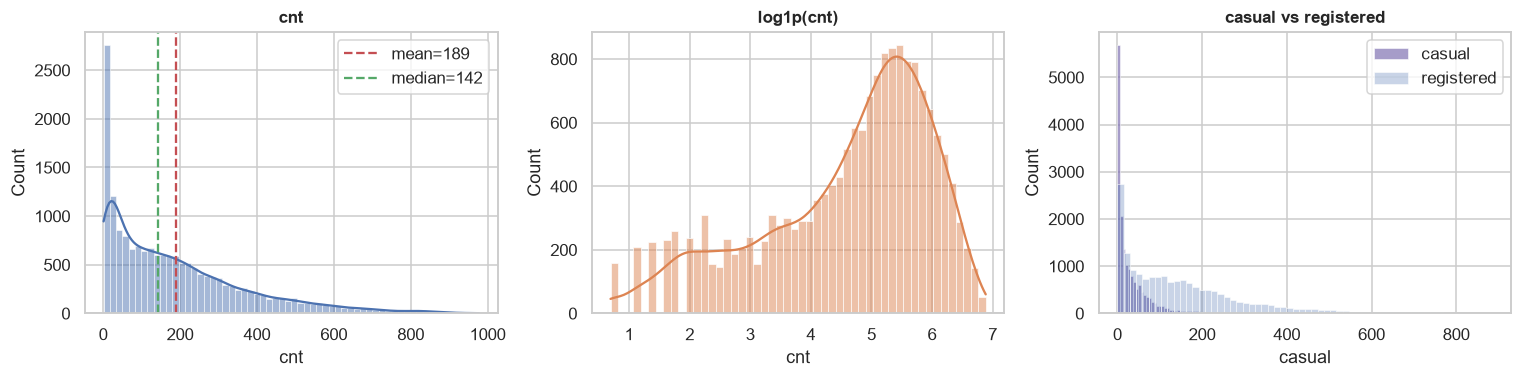

skew(cnt) = 1.28 | skew(log1p(cnt)) = -0.82


In [43]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
sns.histplot(df.cnt, bins=60, kde=True, ax=ax[0]); ax[0].set_title("cnt")
ax[0].axvline(df.cnt.mean(), color="C3", ls="--", label=f"mean={df.cnt.mean():.0f}")
ax[0].axvline(df.cnt.median(), color="C2", ls="--", label=f"median={df.cnt.median():.0f}"); ax[0].legend()
sns.histplot(np.log1p(df.cnt), bins=50, kde=True, ax=ax[1], color="C1"); ax[1].set_title("log1p(cnt)")
sns.histplot(df.casual, bins=60, ax=ax[2], color="C4", label="casual", alpha=.7)
sns.histplot(df.registered, bins=60, ax=ax[2], color="C0", label="registered", alpha=.3); ax[2].legend(); ax[2].set_title("casual vs registered")
plt.tight_layout(); plt.show()
print("skew(cnt) = %.2f | skew(log1p(cnt)) = %.2f" % (df.cnt.skew(), np.log1p(df.cnt).skew()))

**Nhận xét Hình 1.3.** Phân phối của `cnt` lệch phải: các cột cao nhất nằm ở vùng giá trị thấp, đuôi kéo dài đến 977 và đường trung bình (189) nằm bên phải đường trung vị (142), phù hợp với skewness 1.28 ở Bảng 1.3. Nói cách dễ hình dung, trong 100 giờ bất kỳ có khoảng 6 giờ chỉ có từ 1 đến 5 lượt thuê (6.22%) và khoảng 3 giờ có hơn 642 lượt (2.91%); một nửa số giờ có không quá 142 lượt, nhưng vài giờ cao điểm đẩy trung bình lên 189, giống lưu lượng xe trên một con phố: phần lớn thời gian ở mức vừa phải, chỉ vài khung giờ rất đông.

Sau `log1p`, skewness là −0.82, tức độ lệch bị đảo sang trái; histogram có một "bậc" ở khoảng 2–4 và đỉnh chính quanh 5–6, cho thấy `cnt` là sự pha trộn giữa các giờ ít nhu cầu và các giờ nhu cầu cao. Vì vậy `log1p` không đưa `cnt` về dạng chuẩn, và việc có biến đổi hay không sẽ do mô hình ở các phần sau quyết định. Cả `casual` và `registered` đều tập trung gần 0, trong đó `casual` có khối lượng ở giá trị thấp lớn hơn.

**Hình 1.4. Phân phối của `temp`, `atemp`, `hum` và `windspeed` (thang chuẩn hóa 0–1)**

- **Mục đích:** so sánh hình dạng phân phối của bốn biến thời tiết trên cùng thang chuẩn hóa: đối xứng hay lệch, trải rộng đến đâu, có dồn giá trị ở biên hay có cụm bất thường không, và biến nào rời rạc. Việc này kiểm tra xem các bước xử lý ở mục 1.1.2 có để lại bất thường nào không (ví dụ cụm 0 của `hum` đã biến mất chưa), đồng thời cho biết biến nào cần diễn giải thận trọng hoặc có thể cần biến đổi ở các phần sau.
- **Lý do lựa chọn:** cả bốn biến là biến liên tục (hoặc xấp xỉ liên tục) trên cùng thang 0–1 nên histogram kèm KDE là lựa chọn tự nhiên: hiển thị dạng, độ lệch và độ rời rạc. Bốn panel đặt trên cùng một hàng để so sánh trực tiếp. Không dùng boxplot ở đây vì boxplot che mất độ rời rạc và các cột tách nhau của `windspeed`, vốn là thông tin quan trọng; boxplot được dùng ở mục 1.3 khi mục tiêu là các giá trị ngoại lai. Thang chuẩn hóa được giữ nguyên (không quy đổi) để nhất quán với quyết định ở mục 1.1.

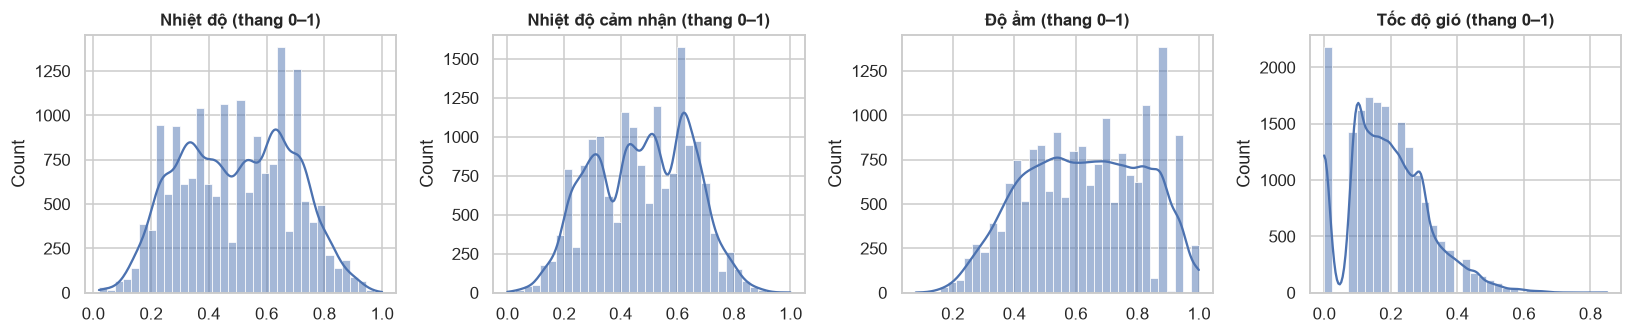

In [44]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
for a, (c, t) in zip(ax, [
    ("temp", "Nhiệt độ (thang 0–1)"),
    ("atemp", "Nhiệt độ cảm nhận (thang 0–1)"),
    ("hum", "Độ ẩm (thang 0–1)"),
    ("windspeed", "Tốc độ gió (thang 0–1)")
]):
    sns.histplot(df[c].dropna(), bins=35, kde=True, ax=a)
    a.set_title(t)
    a.set_xlabel("")
plt.tight_layout()
plt.show()


**Nhận xét Hình 1.4.** `temp` và `atemp` trải gần hết thang 0–1 (0.02 – 1.00 và 0.00 – 1.00), gần đối xứng (skewness −0.01 và −0.09). `hum` trải từ 0.08 đến 1.00 và gần đối xứng (skewness −0.08), không còn cụm giá trị tại 0 sau khi thay 22 giá trị lỗi ở mục 1.1.2. `windspeed` lệch phải (skewness 0.58) và có một cột riêng tại 0 (2,180 dòng, 12.54%); biến này chỉ nhận các mức giá trị rời rạc nên histogram có các cột tách nhau. Như vậy, ba biến đầu không cần xử lý thêm về hình dạng, còn giá trị 0 của `windspeed` là đặc điểm cần ghi nhận khi diễn giải.

**Hình 1.5. Xu hướng theo thời gian của `cnt`**

- **Mục đích:** xác định `cnt` có xu hướng dài hạn (tăng hoặc giảm) và tính mùa vụ (lặp lại theo năm) không. Cụ thể: (i) tổng lượt thuê mỗi ngày thay đổi thế nào qua 731 ngày; (ii) mức tăng giữa 2011 và 2012 có đều giữa các tháng không; (iii) hình dạng mùa vụ của hai năm có giống nhau không. Kết quả quyết định cách chia tập huấn luyện/kiểm tra theo thời gian và việc có cần đưa năm, tháng vào mô hình.
- **Lý do lựa chọn:** biểu đồ đường là lựa chọn chuẩn cho chuỗi thời gian vì nối các điểm liên tiếp, thể hiện được thứ tự và độ liền mạch. Panel trái vẽ tổng theo ngày (đường mờ) cùng trung bình trượt 7 ngày (đường đậm): số liệu ngày dao động theo thời tiết từng ngày và các ngày thiếu giờ, còn trung bình trượt 7 ngày (đúng một chu kỳ tuần) lọc bớt nhiễu đó để lộ xu hướng. Panel phải gộp theo tháng và vẽ hai đường (2011, 2012) chồng trên cùng một trục tháng, cho phép so sánh trực tiếp cùng một tháng giữa hai năm, điều mà một đường liền 24 tháng làm khó thấy. Không dùng biểu đồ cột theo tháng vì cột không thể hiện được sự liên tục, và việc chồng hai năm bằng cột rất khó đọc.

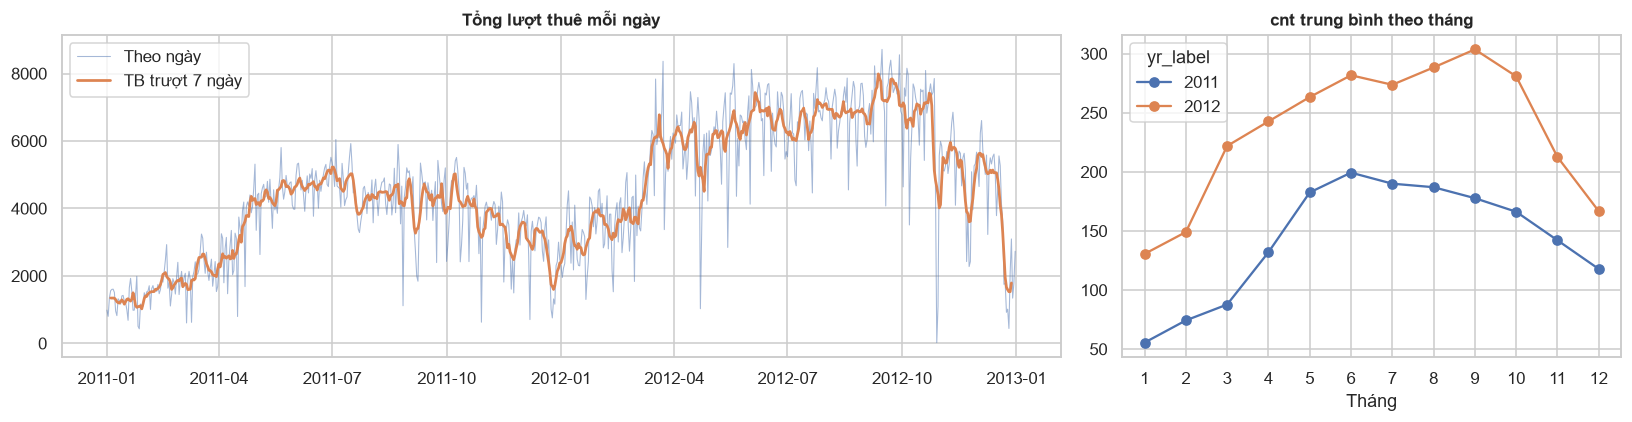

{'2011': 143.8, '2012': 234.7} → tăng 63%


In [45]:
daily = df.groupby("dteday")["cnt"].sum()
fig, ax = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [2, 1]})
ax[0].plot(daily.index, daily.values, lw=.7, alpha=.5, label="Theo ngày")
ax[0].plot(daily.index, daily.rolling(7, center=True).mean(), lw=1.8, label="TB trượt 7 ngày")
ax[0].set_title("Tổng lượt thuê mỗi ngày")
ax[0].legend()

monthly = df.assign(yr_label=df["yr"].map(yr_map)).groupby(["yr_label", "mnth"])["cnt"].mean().unstack(0)
monthly.plot(marker="o", ax=ax[1])
ax[1].set_title("cnt trung bình theo tháng")
ax[1].set_xlabel("Tháng")
ax[1].set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

yr_mean = df.assign(yr_label=df["yr"].map(yr_map)).groupby("yr_label")["cnt"].mean()
print(yr_mean.round(1).to_dict(), "→ tăng %.0f%%" % ((yr_mean["2012"] / yr_mean["2011"] - 1) * 100))


**Nhận xét Hình 1.5.** Có hai đặc điểm theo thời gian. Thứ nhất là xu hướng tăng: `cnt` trung bình năm 2012 là 234.67, cao hơn 63.20% so với 143.79 của năm 2011, và cả 12 tháng của 2012 đều cao hơn tháng tương ứng của 2011. Thứ hai là tính mùa vụ: trung bình theo tháng thấp nhất vào tháng 1 (55.51 năm 2011; 130.56 năm 2012), tăng qua mùa xuân và đạt đỉnh vào tháng 6 năm 2011 (199.32) và tháng 9 năm 2012 (303.57), rồi giảm về cuối năm. Đường trung bình trượt 7 ngày biến đổi chậm, tức các ngày liền kề có mức thuê gần nhau (tự tương quan – autocorrelation). Điểm sụt sâu nhất, cuối tháng 10 năm 2012, là ngày 2012-10-29 với tổng 22 lượt nhưng chỉ có 1/24 giờ được ghi nhận (xem mục 1.3.1). Xu hướng và mùa vụ cùng tồn tại nên khi so sánh giữa các nhóm cần tính đến thời điểm quan sát.

**Hình 1.6. `cnt`, `registered` và `casual` trung bình theo giờ, tách theo loại ngày** (kèm **Bảng 1.8. `cnt` trung bình theo `hr` và `workingday`**)

- **Mục đích:** mô tả nhu cầu thay đổi thế nào trong một ngày (24 giờ) và hình dạng đó có khác nhau giữa ngày làm việc và ngày nghỉ không; tách thêm `registered` và `casual` để xác định nhóm khách nào tạo ra các đỉnh nhu cầu. Đây là câu hỏi trung tâm vì `hr` là biến có liên hệ mạnh nhất với `cnt` (Hình 1.9), và kết quả cho biết có cần xét tương tác `hr` × `workingday` khi mô hình hóa hay không.
- **Lý do lựa chọn:** `hr` là biến có thứ tự và có tính chu kỳ nên biểu đồ đường với `hr` trên trục hoành là phù hợp: nối các điểm cho thấy hình dạng (một hay hai đỉnh, độ dốc), điều mà biểu đồ cột 24 thanh thể hiện kém. Hai đường theo `workingday` đặt trên cùng khung để so sánh trực tiếp. Dải khoảng tin cậy 95% quanh đường trung bình cho biết độ bất định của từng trung bình giờ. Ba panel `cnt`, `registered`, `casual` dùng chung trục tung để so sánh độ lớn tuyệt đối giữa các nhóm: nếu mỗi panel có trục riêng thì đỉnh của `casual` trông ngang với `registered` dù nhỏ hơn nhiều. Bảng 1.8 bổ sung các giá trị cụ thể để trích dẫn trong nhận xét.

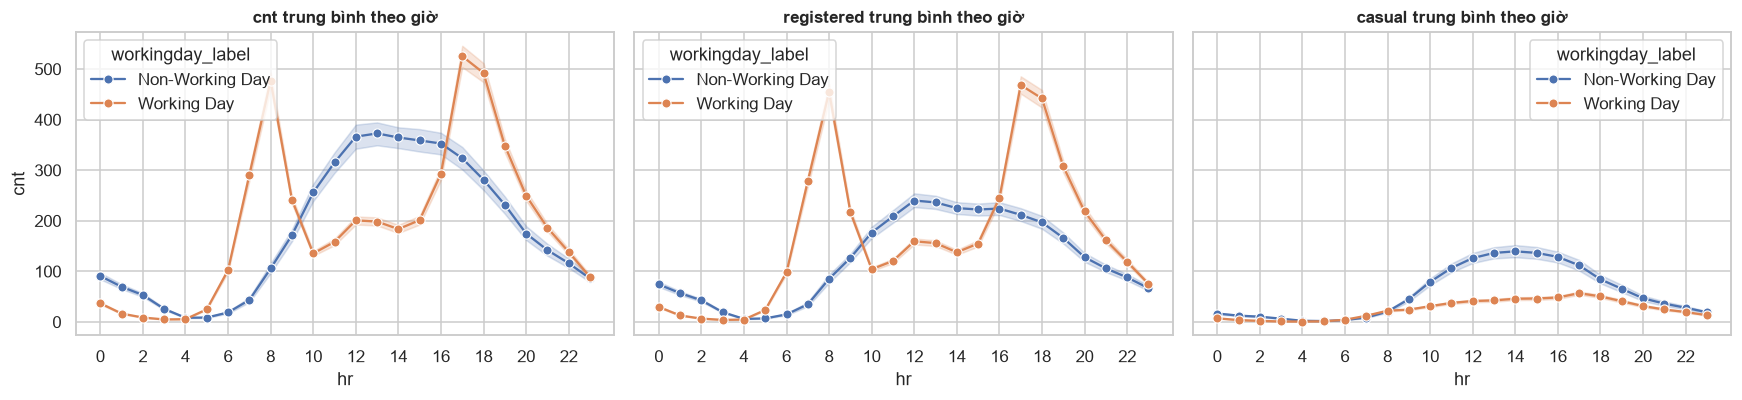

hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
workingday_label,,,,,,,,,,,,,,,,,,,,,
Non-Working Day,91.0,70.0,53.0,26.0,8.0,9.0,19.0,43.0,106.0,172.0,...,365.0,359.0,353.0,324.0,281.0,232.0,175.0,142.0,116.0,86.0
Working Day,37.0,17.0,9.0,5.0,5.0,25.0,102.0,291.0,477.0,242.0,...,184.0,201.0,293.0,525.0,492.0,348.0,250.0,186.0,138.0,89.0


In [46]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8), sharey=True)
for a, col in zip(ax, ["cnt", "registered", "casual"]):
    sns.lineplot(
        data=df_eda, x="hr", y=col, hue="workingday_label",
        estimator="mean", errorbar=("ci", 95), marker="o", ax=a
    )
    a.set_title(f"{col} trung bình theo giờ")
    a.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

pivot_hr = df_eda.pivot_table(
    index="hr", columns="workingday_label", values="cnt", aggfunc="mean"
).round(0)
pivot_hr.T


**Nhận xét Hình 1.6 và Bảng 1.8.** Nhịp theo giờ của hai loại ngày khác hẳn nhau, giống hai nhịp tim khác nhau của thành phố. Ở ngày làm việc, `cnt` trung bình có hai đỉnh: 477.01 lượt lúc 8 giờ và 525.29 lượt lúc 17 giờ (492.23 lúc 18 giờ), trong đó nhóm `registered` chiếm 95.33% ở 8 giờ và 89.17% ở 17 giờ; hình dạng này giống nhịp đi làm, đi học lặp lại mỗi ngày, dù dữ liệu không ghi mục đích chuyến đi. Ở ngày nghỉ không có cao điểm sáng: nhu cầu dâng dần từ trưa đến khoảng 17 giờ, cao nhất lúc 13 giờ (372.73), và `casual` chiếm 36.60% (136.42/372.73), gần 8 lần tỷ trọng của đỉnh sáng ngày làm việc (4.67%), giống những chuyến đi dạo và giải trí.

Nhu cầu thấp nhất ở khoảng 3–5 giờ sáng; `cnt` trung bình lúc 3 giờ (11.73) chỉ bằng khoảng 1/39 mức lúc 17 giờ (461.45). Như vậy `hr` có liên hệ chặt với `cnt`, và dạng liên hệ phụ thuộc vào `workingday`, nên khi mô hình hóa cần xét tương tác giữa hai biến này.

**Hình 1.7. Phân phối của `cnt` theo `season` và `weathersit`**

- **Mục đích:** so sánh mức trung tâm (median) và độ phân tán của `cnt` giữa các mùa và giữa các mức thời tiết, đồng thời xem các nhóm có chồng lấn nhiều không. Kết quả cho biết `season` và `weathersit` phân biệt được các mức nhu cầu tới đâu, và nhóm nào có quá ít quan sát để so sánh (Heavy Rain / Snow).
- **Lý do lựa chọn:** `cnt` lệch phải nên so sánh nhóm bằng trung bình đơn thuần sẽ bị đuôi kéo lệch; boxplot hiển thị đồng thời median, Q1/Q3, râu và các điểm vượt râu của từng nhóm nên thấy được cả mức điển hình lẫn độ rộng và độ lệch. Hai panel đặt cạnh nhau với **cùng thang trục tung** để so sánh độ lớn giữa mùa và thời tiết. Điểm trung bình (◆) được thêm cạnh đường median để thấy chênh lệch giữa mean và median ở từng nhóm, chênh lệch này phản ánh độ lệch phải; cỡ mẫu `n` được ghi ở nhãn trục vì độ tin cậy của một hộp phụ thuộc vào số quan sát, đặc biệt với nhóm chỉ có 3 dòng. Mỗi nhóm một màu để dễ phân biệt, màu không mã hóa thêm thông tin nào khác. Biểu đồ cột trung bình cho `weekday` và `holiday` không được dùng vì khác biệt nhỏ và các hệ số tương quan đã có ở Bảng 1.9.

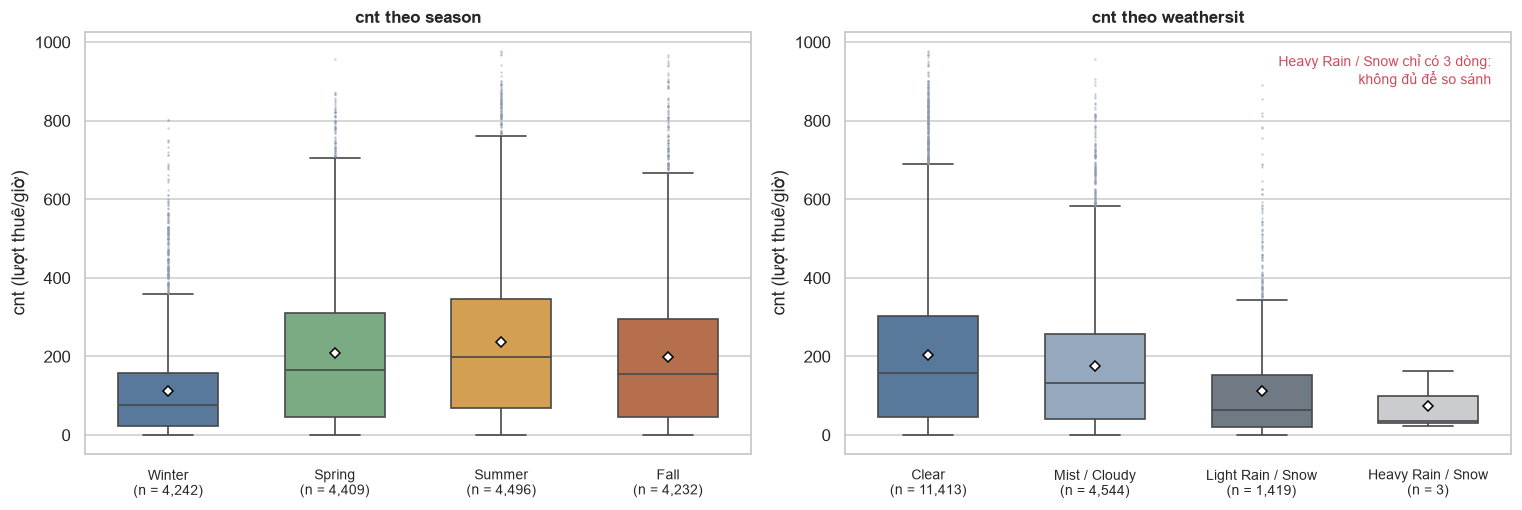

In [47]:
BLUE, RED, GREY = "#3b6ea5", "#d1495b", "#8d99ae"

def style_box(ax, data, x, order, colors, labels):
    sns.boxplot(data=data, x=x, y="cnt", order=order, hue=x, hue_order=order, palette=dict(zip(order, colors)),
                legend=False, width=0.6, linewidth=1.1, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=5),
                flierprops=dict(marker=".", markersize=3, markerfacecolor=GREY, markeredgecolor="none", alpha=0.5), ax=ax)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{l}\n(n = {(data[x] == k).sum():,})" for k, l in zip(order, labels)], fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("cnt (lượt thuê/giờ)")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))

style_box(ax[0], df_eda, "season_label", season_order, ["#4c78a8", "#72b37e", "#e8a33d", "#c8693b"], season_order)
ax[0].set_title("cnt theo season")

style_box(ax[1], df_eda, "weather_label", weather_order, ["#4c78a8", "#8fa8c4", "#6c7a89", "#c9ccd1"], weather_order)
ax[1].set_title("cnt theo weathersit    ")
ax[1].text(0.97, 0.95, "Heavy Rain / Snow chỉ có 3 dòng:\nkhông đủ để so sánh", transform=ax[1].transAxes,
           ha="right", va="top", fontsize=9, color=RED)

plt.tight_layout(); plt.show()

**Nhận xét Hình 1.7.** Trung vị của `cnt` tăng từ Winter (76) lên Spring (165) và Summer (199), rồi giảm ở Fall (155.5); trung vị của Winter thấp hơn một nửa so với Spring, và về trung bình giờ mùa hè (236.02) gấp 2.12 lần giờ mùa đông (111.11). Các hộp của Spring, Summer và Fall chồng lấn nhiều, nên biết mùa chỉ giúp đoán "mức nền" chứ chưa đoán được một giờ cụ thể; muốn vậy còn cần biết giờ trong ngày (Hình 1.6).

Theo `weathersit`, trung vị giảm từ 159 (Clear) xuống 133 (Mist / Cloudy) và 63 (Light Rain / Snow), tức một giờ trời quang có trung vị gấp khoảng 2.52 lần giờ có mưa hoặc tuyết nhẹ. Nhóm Heavy Rain / Snow chỉ gồm 3 giờ thuộc 3 ngày khác nhau (trung vị 36), nên không thể dùng làm bằng chứng cho việc "có bão thì không ai đi xe". Trừ nhóm này, mọi nhóm đều có nhiều điểm vượt râu trên, phù hợp với phân phối lệch phải của `cnt`. Vì vậy `season` và `weathersit` đi cùng những mức `cnt` khác nhau, nhưng biến động trong từng nhóm vẫn lớn, một phần do khác biệt giữa các giờ trong ngày, nên cần xét kết hợp với `hr`. Liên hệ của `weekday` và `holiday` với `cnt` được trình bày ở Bảng 1.9 và Hình 1.9.

**Hình 1.8. Quan hệ giữa `temp`, `hum`, `windspeed` (thang chuẩn hóa) và `cnt`**

- **Mục đích:** xem chiều và dạng quan hệ giữa từng biến thời tiết liên tục và `cnt`: dương hay âm, đơn điệu hay không, tuyến tính hay cong, đồng nhất hay chỉ có ở một vài vùng giá trị. Biểu đồ cũng cho thấy mức phân tán của `cnt` ở mỗi mức thời tiết, từ đó ước lượng (ở mức mô tả) thời tiết đi cùng bao nhiêu biến động của `cnt`.
- **Lý do lựa chọn:** cả hai biến đều liên tục nên biểu đồ phân tán là lựa chọn chuẩn để xem dạng quan hệ. Với 17,379 điểm, các điểm chồng lên nhau, nên dùng độ trong suốt thấp (`alpha = 0.12`) để vùng dày hiện thành vùng đậm hơn, và thêm đường trung bình `cnt` theo 15 khoảng của biến để thấy xu hướng mà đám mây điểm che mất. Hệ số **Spearman** (ghi ở tiêu đề mỗi panel) được chọn thay cho Pearson vì `cnt` lệch phải và quan hệ có thể không tuyến tính; Spearman đo xu hướng đơn điệu theo thứ hạng và ít bị ảnh hưởng bởi giá trị cực đoan. Ba panel đặt cạnh nhau để so sánh độ mạnh và hình dạng của ba biến.

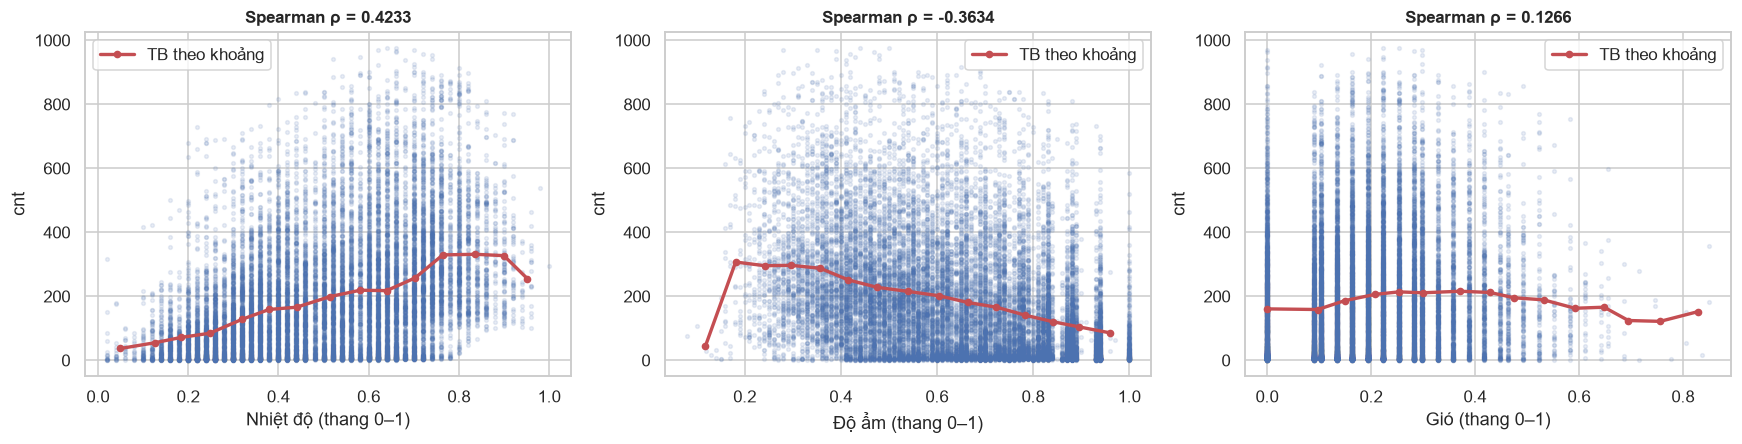

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for a, (c, t) in zip(ax, [
    ("temp", "Nhiệt độ (thang 0–1)"),
    ("hum", "Độ ẩm (thang 0–1)"),
    ("windspeed", "Gió (thang 0–1)")
]):
    sub = df[[c, "cnt"]].dropna()
    a.scatter(sub[c], sub["cnt"], s=6, alpha=.12)
    bins = pd.cut(sub[c], 15)
    m = sub.groupby(bins, observed=True).agg(x=(c, "mean"), y=("cnt", "mean"))
    a.plot(m.x, m.y, lw=2.2, marker="o", ms=4, label="TB theo khoảng", color="C3")
    a.legend()
    a.set_xlabel(t)
    a.set_ylabel("cnt")
    r, p = stats.spearmanr(sub[c], sub["cnt"])
    a.set_title(f"Spearman ρ = {r:.4f}")
plt.tight_layout()
plt.show()


**Nhận xét Hình 1.8.** `temp` có tương quan dương với `cnt` (Spearman ρ = 0.4233): trung bình `cnt` tăng đều qua các khoảng của `temp`, từ 65.07 ở khoảng 0–0.2 (1,070 giờ) lên 123.07, 194.67, 260.70 và 326.28 ở khoảng 0.8–1.0 (709 giờ), gấp 5.01 lần; nói cách khác, những giờ lạnh nhất là lúc ít người đi xe nhất. `hum` có tương quan âm (ρ = −0.3634): từ 0.4 trở lên, trung bình giảm từ 221.75 (0.4–0.6) xuống 172.41 và 107.17 (0.8–1.0), gần bằng một nửa. Độ ẩm cao thường đi cùng thời tiết u ám hoặc mưa (tương quan giữa `hum` và `weathersit` là 0.4151), nên hai yếu tố này khó tách rời.

`windspeed` có tương quan yếu (ρ = 0.1266) và quan hệ không đơn điệu: không thấy xu hướng giảm ở gió nhẹ đến vừa (184.98 – 213.81 ở các khoảng 0.1–0.4), chỉ khi gió rất mạnh (0.6–0.9) trung bình mới giảm còn 156.17, nhưng chỉ có 63 giờ như vậy. Đám mây điểm rộng ở mọi mức của ba biến vì `cnt` còn biến động theo giờ trong ngày (Hình 1.6), và giờ ấm cũng thường là giờ giữa ngày của mùa hè, nên các kết quả này mô tả sự đi cùng giữa các biến, chưa đủ để kết luận quan hệ nhân quả.

**Hình 1.9. Ma trận tương quan Spearman và `cnt` trung bình theo `weekday` × `hr`**

- **Mục đích:** (i) đo mức tương quan giữa các biến với nhau để phát hiện các cặp có tương quan cao (rủi ro đa cộng tuyến và rò rỉ dữ liệu) và biến nào liên hệ mạnh với `cnt`; (ii) xem sự kết hợp giữa thứ trong tuần và giờ trong ngày, tức hình dạng nhu cầu theo giờ của từng thứ, vì từng biến riêng lẻ không cho thấy tương tác này.
- **Lý do lựa chọn:** heatmap cho phép đọc nhiều cặp tương quan (12 × 12) trong một hình, với thang màu phân kỳ có tâm ở 0 (đỏ cho tương quan dương, xanh cho tương quan âm) để thấy ngay chiều và độ mạnh; số trong ô dùng để trích dẫn. Spearman được chọn vì `cnt` lệch phải, `hr`, `season`, `weathersit` là biến thứ bậc và quan hệ không nhất thiết tuyến tính. Panel phải là heatmap `weekday` × `hr` với giá trị là `cnt` trung bình: ma trận 7 × 24 = 168 ô cho thấy hình dạng theo giờ của cả bảy thứ cùng lúc, điều mà bảng 168 giá trị khó đọc và bảy đường chồng nhau sẽ rối. Thang màu tuần tự (vàng đến đỏ) phù hợp vì giá trị chỉ có chiều lớn nhỏ.

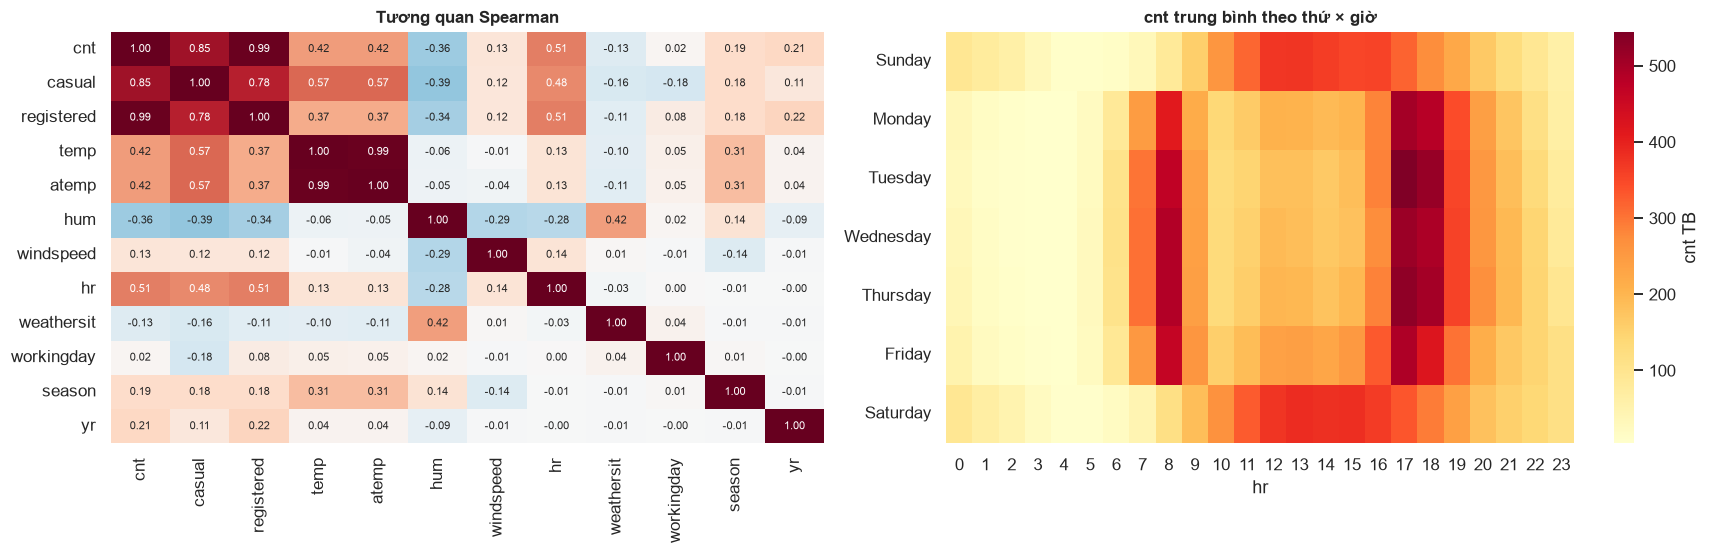

In [49]:
corr_cols = [
    "cnt", "casual", "registered", "temp", "atemp", "hum", "windspeed",
    "hr", "weathersit", "workingday", "season", "yr"
]
fig, ax = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1, 1.1]})

sns.heatmap(
    df[corr_cols].corr(method="spearman"),
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    ax=ax[0], cbar=False, annot_kws={"size": 7}
)
ax[0].set_title("Tương quan Spearman")

hm = df_eda.pivot_table(
    index="weekday_label", columns="hr", values="cnt", aggfunc="mean"
).reindex(day_order)
sns.heatmap(hm, cmap="YlOrRd", ax=ax[1], cbar_kws={"label": "cnt TB"})
ax[1].set_title("cnt trung bình theo thứ × giờ")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Bảng 1.9. Hệ số tương quan giữa các biến và `cnt`** (sắp xếp theo |Spearman|)

In [50]:
corr_vars = ["hr", "temp", "atemp", "hum", "windspeed", "weathersit", "season", "yr", "mnth",
             "workingday", "holiday", "weekday", "registered", "casual"]
corr_tbl = pd.DataFrame({
    "Spearman": [stats.spearmanr(df[c], df["cnt"])[0] for c in corr_vars],
    "Pearson":  [df[c].corr(df["cnt"]) for c in corr_vars],
}, index=corr_vars).round(4).sort_values("Spearman", key=abs, ascending=False)
display(corr_tbl)
print("corr(temp, atemp): Pearson = %.4f | Spearman = %.4f" % (df["temp"].corr(df["atemp"]), stats.spearmanr(df["temp"], df["atemp"])[0]))
print("corr(hum, weathersit)  : Spearman = %.4f" % stats.spearmanr(df["hum"], df["weathersit"])[0])
print("corr(temp, season)     : Spearman = %.4f" % stats.spearmanr(df["temp"], df["season"])[0])

,Spearman,Pearson
registered,0.9894,0.9722
casual,0.8505,0.6946
hr,0.5109,0.3941
temp,0.4233,0.4048
atemp,0.4233,0.4009
hum,-0.3634,-0.3292
yr,0.2075,0.2505
season,0.1852,0.1781
windspeed,0.1266,0.0932
weathersit,-0.1263,-0.1424


corr(temp, atemp): Pearson = 0.9877 | Spearman = 0.9896
corr(hum, weathersit)  : Spearman = 0.4151
corr(temp, season)     : Spearman = 0.3058


**Nhận xét Hình 1.9 và Bảng 1.9.**

- **Tương quan với `cnt` (Spearman).** `hr` = 0.5109, `temp` = 0.4233 (`atemp` = 0.4233), `hum` = −0.3634, `yr` = 0.2075, `season` = 0.1852, `windspeed` = 0.1266 và `weathersit` = −0.1263. Đây là mối liên hệ đi cùng, không phải bằng chứng nhân quả. Các biến thời tiết cũng liên hệ với biến khác (`hum` và `weathersit`: 0.4151; `temp` và `season`: 0.3058), nên liên hệ riêng lẻ với `cnt` chưa tách được khỏi các yếu tố đi kèm.
- **Hệ số thấp không có nghĩa là không liên quan.** `hr` chỉ đạt 0.5109 dù Hình 1.6 cho thấy chênh lệch rất lớn giữa các giờ, vì quan hệ có chu kỳ (tăng – giảm – tăng – giảm) không đơn điệu. `workingday` (0.0210), `weekday` (0.0303) và `holiday` (−0.0295) gần 0, nhưng hình dạng theo giờ giữa các loại ngày khác nhau rõ (Hình 1.6); hệ số chỉ đo xu hướng đơn điệu của mức trung bình.
- **Heatmap `weekday` × `hr`.** Từ thứ Hai đến thứ Sáu có hai dải cao lúc 8 giờ và 17–18 giờ; thứ Bảy và Chủ nhật có một dải rộng khoảng 11–16 giờ. Giá trị trung bình cao nhất là thứ Ba lúc 17 giờ (544.28).
- **Đa cộng tuyến (multicollinearity).** `temp` và `atemp` có tương quan 0.9877 (Pearson) và 0.9896 (Spearman); đưa cả hai vào mô hình tuyến tính sẽ gây đa cộng tuyến mà gần như không thêm thông tin.
- **Rò rỉ dữ liệu (data leakage).** `registered` (0.9894) và `casual` (0.8505) có tương quan rất cao với `cnt` vì `cnt = casual + registered`. Hai biến này chỉ dùng để mô tả, không được dùng làm biến độc lập khi dự đoán `cnt`.

## 1.3. Phát hiện và xử lý giá trị ngoại lai

**Mục tiêu.** Xác định các quan sát nằm xa phần lớn dữ liệu, sau đó phân biệt giá trị ngoại lai thống kê (statistical outlier) với lỗi dữ liệu (data error) để quyết định giữ hay xử lý. Mục này không mặc định xóa giá trị ngoại lai.

### 1.3.1. Phát hiện

**Phương pháp.** (1) Quy tắc IQR: một giá trị bị đánh dấu nếu nhỏ hơn Q1 − 1.5×IQR hoặc lớn hơn Q3 + 1.5×IQR. (2) Z-score: đánh dấu nếu |z| > 3. (3) Boxplot để quan sát trực quan. Vì `cnt` phụ thuộc mạnh vào `hr` (Hình 1.6), ngưỡng IQR tính trên toàn bộ dữ liệu có thể coi các đỉnh giờ cao điểm là bất thường; do đó bổ sung ngưỡng tính riêng theo `hr`, theo cặp (`hr`, `workingday`) và theo tổng lượt thuê mỗi ngày.

**Bảng 1.10. Kết quả phát hiện giá trị ngoại lai bằng IQR và Z-score**

In [51]:
def iqr_bounds(s):
    q1, q3 = s.quantile([.25, .75])
    i = q3 - q1
    return q1 - 1.5 * i, q3 + 1.5 * i

rows = []
for c in ["cnt", "casual", "registered", "temp", "hum", "windspeed"]:
    s = df[c].dropna()
    lo, hi = iqr_bounds(s)
    z = np.abs(stats.zscore(s))
    rows.append({
        "biến": c,
        "hàng rào dưới": round(lo, 3),
        "hàng rào trên": round(hi, 3),
        "outlier IQR": int(((s < lo) | (s > hi)).sum()),
        "% IQR": round(((s < lo) | (s > hi)).mean() * 100, 2),
        "outlier |z|>3": int((z > 3).sum()),
        "% z": round((z > 3).mean() * 100, 2)
    })

pd.DataFrame(rows).set_index("biến")


,hàng rào dưới,hàng rào trên,outlier IQR,% IQR,outlier |z|>3,% z
biến,,,,,,
cnt,-321.500,642.500,505,2.91,244,1.40
casual,-62.000,114.000,1192,6.86,467,2.69
registered,-245.000,499.000,680,3.91,371,2.13
temp,-0.140,1.140,0,0.00,0,0.00
hum,0.030,1.230,0,0.00,0,0.00
windspeed,-0.119,0.477,342,1.97,107,0.62


**Nhận xét Bảng 1.10.** Hàng rào IQR của `cnt` là [−321.50, 642.50], nên chỉ có giá trị ngoại lai phía trên: 505 dòng (2.91%). Z-score (|z| > 3) chỉ đánh dấu 244 dòng (1.40%) vì trung bình và độ lệch chuẩn đều bị đuôi phải kéo lên (ngưỡng tương ứng khoảng 733.6); phương pháp này vốn giả định phân phối gần chuẩn, điều kiện mà `cnt` không thỏa (skewness 1.28). `casual` (1,192 dòng; 6.86%) và `registered` (680 dòng; 3.91%) bị đánh dấu nhiều hơn `cnt` do phân phối của chúng lệch mạnh hơn. Trong các biến thời tiết (thang chuẩn hóa), `temp` và `hum` không có giá trị ngoại lai; `windspeed` có 342 dòng (1.97%) vượt hàng rào trên 0.477, với giá trị lớn nhất là 0.85. Như vậy giá trị ngoại lai tập trung ở các biến đếm và `windspeed`, phù hợp với các phân phối lệch phải ở mục 1.2.

**Hình 1.10. Boxplot của `cnt` (toàn bộ và theo `hr`) và của các biến thời tiết**

- **Mục đích:** quan sát trực quan các giá trị vượt hàng rào IQR của `cnt` ở ba cách nhìn: toàn bộ dữ liệu, từng giờ và các biến thời tiết, để xem giá trị ngoại lai tập trung ở đâu. Đặc biệt, hình kiểm tra việc dùng **một ngưỡng chung cho cả ngày** có đánh dấu nhầm các giờ cao điểm (vốn nhu cầu cao một cách bình thường) là bất thường không, so với việc dùng ngưỡng riêng theo giờ.
- **Lý do lựa chọn:** boxplot hiển thị đồng thời median, Q1/Q3 và các điểm ngoài hàng rào theo quy tắc 1.5 × IQR, nên gắn trực tiếp với phương pháp phát hiện ở mục 1.3.1. Panel 1 và 2 dùng **chung trục tung** và cùng một đường đỏ nằm ngang tại hàng rào toàn cục (642.5) để thấy ngay giờ nào có hộp hoặc râu chạm hàng rào; ba giờ 8, 17, 18 tô cam để nhấn mạnh chúng là các giờ cao điểm. Việc chia theo 24 giờ là cần thiết vì `cnt` phụ thuộc mạnh vào giờ (Hình 1.6) nên một ngưỡng chung không phản ánh được phân phối của từng giờ. Panel 3 dùng boxplot cho `temp`, `hum`, `windspeed` trên cùng thang 0–1 và ghi số dòng ngoài hàng rào dưới tên biến để đối chiếu với Bảng 1.10; boxplot được chọn thay cho histogram vì mục tiêu ở đây là xác định điểm vượt râu, không phải hình dạng phân phối.

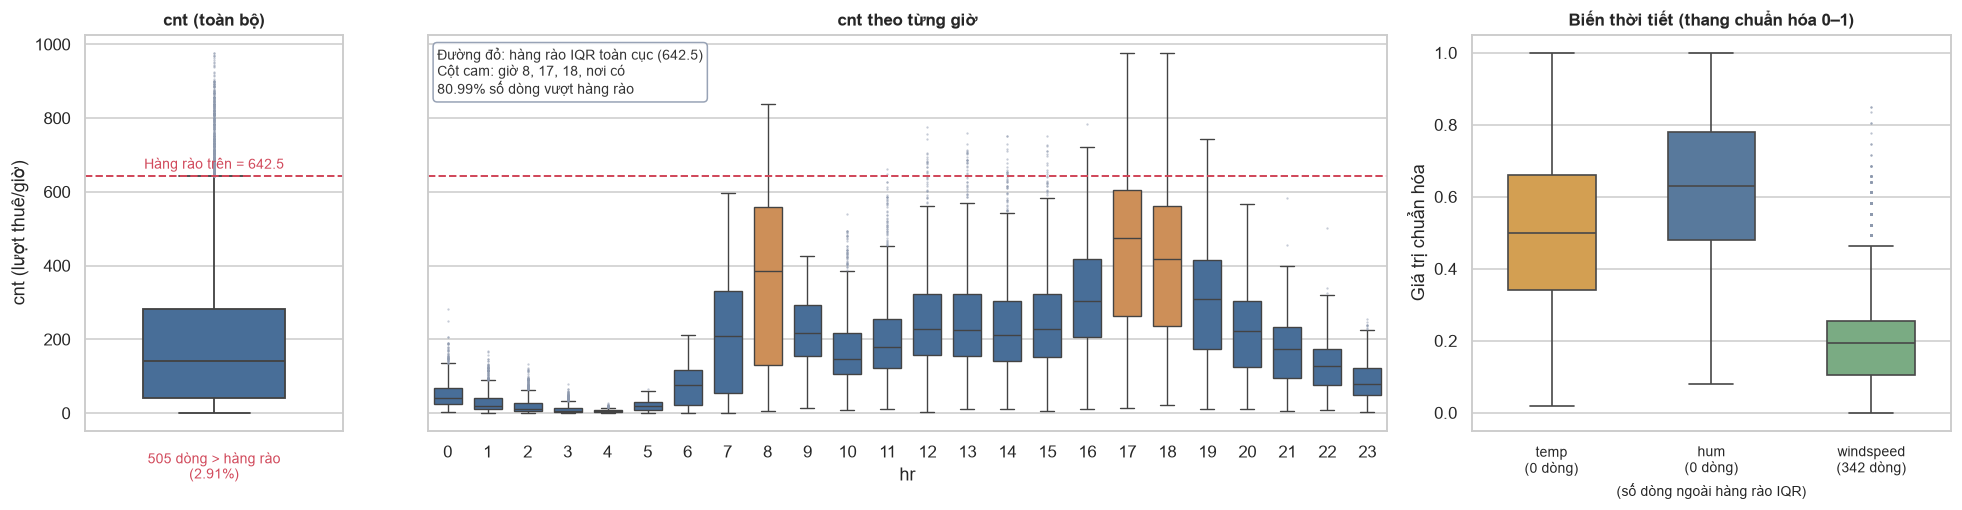

In [52]:
BLUE, ORANGE, RED, GREY = "#3b6ea5", "#e08e45", "#d1495b", "#8d99ae"
lo_cnt, hi_cnt = iqr_bounds(df["cnt"])
n_out = int((df["cnt"] > hi_cnt).sum())

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8), gridspec_kw={"width_ratios": [0.7, 2.6, 1.3]})
ax[1].sharey(ax[0])

# (1) cnt toàn bộ
sns.boxplot(y=df["cnt"], ax=ax[0], color=BLUE, width=0.55, linewidth=1.2,
            flierprops=dict(marker=".", markersize=3, markerfacecolor=GREY, markeredgecolor="none", alpha=0.5))
ax[0].axhline(hi_cnt, color=RED, ls="--", lw=1.3)
ax[0].text(0.5, hi_cnt + 12, f"Hàng rào trên = {hi_cnt:.1f}", transform=ax[0].get_yaxis_transform(), ha="center", va="bottom", color=RED, fontsize=9)
ax[0].set_title("cnt (toàn bộ)")
ax[0].set_xlabel(f"{n_out} dòng > hàng rào\n({n_out / len(df):.2%})", color=RED, fontsize=9)
ax[0].set_ylabel("cnt (lượt thuê/giờ)")

# (2) cnt theo từng giờ: giờ cao điểm 8, 17, 18 tô cam
peak_hours = {8, 17, 18}
pal = {h: (ORANGE if h in peak_hours else BLUE) for h in range(24)}
sns.boxplot(data=df, x="hr", y="cnt", hue="hr", palette=pal, legend=False, ax=ax[1], width=0.7, linewidth=0.9,
            flierprops=dict(marker=".", markersize=3, markerfacecolor=GREY, markeredgecolor="none", alpha=0.5))
ax[1].axhline(hi_cnt, color=RED, ls="--", lw=1.3)
share_peak = df.loc[df["cnt"] > hi_cnt, "hr"].isin(peak_hours).mean()
ax[1].text(0.01, 0.97, f"Đường đỏ: hàng rào IQR toàn cục ({hi_cnt:.1f})\nCột cam: giờ 8, 17, 18, nơi có\n{share_peak:.2%} số dòng vượt hàng rào",
           transform=ax[1].transAxes, ha="left", va="top", fontsize=9, color="#333",
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GREY, alpha=0.9))
ax[1].set_title("cnt theo từng giờ")
ax[1].set_xlabel("hr"); ax[1].set_ylabel("")
ax[1].tick_params(labelleft=False)

# (3) Các biến thời tiết (thang chuẩn hóa 0–1)
w_vars = ["temp", "hum", "windspeed"]
w_cols = {"temp": "#e8a33d", "hum": "#4c78a8", "windspeed": "#72b37e"}
weather_long = df[w_vars].melt(var_name="variable", value_name="value")
sns.boxplot(data=weather_long, x="variable", y="value", order=w_vars, hue="variable", hue_order=w_vars, palette=w_cols,
            legend=False, ax=ax[2], width=0.55, linewidth=1.1,
            flierprops=dict(marker=".", markersize=3, markerfacecolor=GREY, markeredgecolor="none", alpha=0.6))
labels = []
for v in w_vars:
    l, h = iqr_bounds(df[v]); n = int(((df[v] < l) | (df[v] > h)).sum())
    labels.append(f"{v}\n({n} dòng)")
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(labels, fontsize=9)
ax[2].set_title("Biến thời tiết (thang chuẩn hóa 0–1)")
ax[2].set_xlabel("(số dòng ngoài hàng rào IQR)", fontsize=9); ax[2].set_ylabel("Giá trị chuẩn hóa")

plt.tight_layout(); plt.show()

**Nhận xét Hình 1.10.** Ở boxplot theo giờ, median và hộp tăng ở 7–9 giờ và 16–19 giờ, trong khi gần như mọi giờ khác đều có điểm vượt râu trên. Ngưỡng IQR toàn cục (642.5) cho thấy điểm yếu của việc dùng một ngưỡng cho cả ngày: một quy tắc "giờ nào quá 642 lượt là bất thường" sẽ báo động đúng vào giờ tan tầm, tức giờ hệ thống bận nhất. Khi tính ngưỡng riêng theo `hr`, 533 dòng (3.07%) bị đánh dấu, nằm ở các giờ 0–5 (53.85%), 10–16 và 21–23, và không có dòng nào ở các giờ cao điểm 8, 17, 18: hộp của 17 giờ trải từ 262.25 đến 604.75 lượt và râu trên lên tới 976 mà không có điểm nào bị đánh dấu, tức mức đông ở giờ đó là bình thường của giờ đó.

Ngược lại, lúc 3 giờ sáng trung vị chỉ là 6 lượt nên 60 đêm có từ 34 đến 79 lượt bị đánh dấu là đông bất thường dù con số tuyệt đối còn rất nhỏ. Thêm nữa, 85.93% số dòng bị đánh dấu theo giờ thuộc năm 2012, nên ngưỡng theo giờ còn phản ánh xu hướng tăng giữa hai năm (Hình 1.5). Kết quả phát hiện vì vậy phụ thuộc vào cách chọn ngưỡng: cùng một con số có thể bình thường ở giờ này nhưng bất thường ở giờ khác, nên ngưỡng cần gắn với bối cảnh.

**Hình 1.11. Phân bố giá trị ngoại lai toàn cục của `cnt` theo giờ và theo loại ngày**

- **Mục đích:** xác định 505 giá trị `cnt` vượt hàng rào toàn cục rơi vào thời điểm nào (giờ nào, loại ngày nào) để quyết định chúng là biến động thực tế hay lỗi dữ liệu. Nếu chúng dồn vào các giờ cao điểm của ngày làm việc thì phù hợp với hành vi đi làm; nếu rải ngẫu nhiên vào giờ đêm hoặc dồn vào một ngày lạ thì cần nghi ngờ lỗi ghi nhận.
- **Lý do lựa chọn:** câu hỏi chỉ là "bao nhiêu dòng nằm ở đâu", nên biểu đồ cột đếm số dòng theo từng giờ (24 cột) và theo loại ngày (2 cột) là đủ và dễ đọc nhất; scatter hoặc đường không thêm thông tin vì đây là tần số theo nhóm rời rạc. Giờ và loại ngày được chọn vì Hình 1.6 đã chỉ ra đây là hai yếu tố chi phối hình dạng nhu cầu: nếu các giá trị ngoại lai trùng với các đỉnh ở Hình 1.6 thì có cơ sở coi chúng là hợp lệ.

Hàng rào IQR toàn cục cho cnt: [-321.50, 642.50]
Outlier toàn cục             :  505 (2.91%)
Outlier theo từng giờ        :  533 (3.07%)
Outlier theo (giờ, loại ngày):  130 (0.75%)


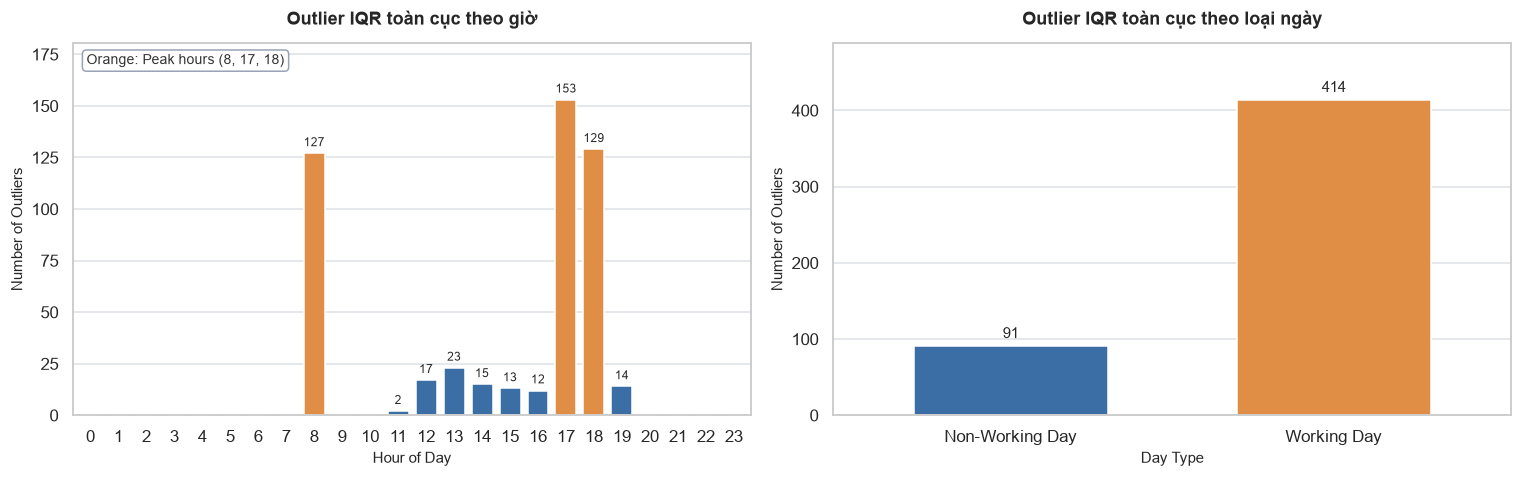

Tỷ lệ outlier toàn cục ở giờ 8, 17, 18 : 80.99%
Tỷ lệ outlier toàn cục ở ngày làm việc  : 81.98%
cnt trung bình của nhóm outlier toàn cục: 749.24 (max = 977)


In [53]:

lo, hi = iqr_bounds(df["cnt"])

def flag_group(s):
    l, h = iqr_bounds(s)
    return ((s < l) | (s > h)).astype(int)

# Không thêm cột vào df: các cờ ngoại lai lưu thành Series riêng
out_global   = ((df["cnt"] < lo) | (df["cnt"] > hi)).astype(int)
out_by_hr    = df.groupby("hr")["cnt"].transform(flag_group)
out_by_hr_wd = df.groupby(["hr", "workingday"])["cnt"].transform(flag_group)

print(f"Hàng rào IQR toàn cục cho cnt: [{lo:.2f}, {hi:.2f}]")
print(f"Outlier toàn cục             : {out_global.sum():>4,} ({out_global.mean():.2%})")
print(f"Outlier theo từng giờ        : {out_by_hr.sum():>4,} ({out_by_hr.mean():.2%})")
print(f"Outlier theo (giờ, loại ngày): {out_by_hr_wd.sum():>4,} ({out_by_hr_wd.mean():.2%})")

g = df[out_global == 1]

# Bảng màu theo style mẫu
BLUE, ORANGE, RED, GREY = "#3b6ea5", "#e08e45", "#d1495b", "#8d99ae"

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# (1) Outlier IQR toàn cục theo giờ
hour_counts = g.groupby("hr").size().reindex(range(24), fill_value=0)
hour_counts.plot.bar(
    ax=ax[0],
    color=[ORANGE if h in [8, 17, 18] else BLUE for h in range(24)],
    edgecolor="white",
    width=0.75
)

ax[0].set_title("Outlier IQR toàn cục theo giờ", fontsize=12, fontweight="bold", pad=12)
ax[0].set_xlabel("Hour of Day", fontsize=10)
ax[0].set_ylabel("Number of Outliers", fontsize=10)
ax[0].set_xticks(range(24))
ax[0].set_xticklabels(range(24), rotation=0)
ax[0].bar_label(
    ax[0].containers[0],
    fmt=lambda x: f"{int(x):,}" if x > 0 else "",
    fontsize=8,
    padding=3
)

ax[0].text(
    0.02, 0.97,
    "Orange: Peak hours (8, 17, 18)",
    transform=ax[0].transAxes,
    ha="left", va="top", fontsize=9, color="#333333",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GREY, alpha=0.9)
)

# (2) Outlier IQR toàn cục theo loại ngày
g["workingday"].map({
    0: "Non-Working Day",
    1: "Working Day"
}).value_counts().reindex([
    "Non-Working Day", "Working Day"
], fill_value=0).plot.bar(
    ax=ax[1],
    color=[BLUE, ORANGE],
    edgecolor="white",
    width=0.6,
    rot=0
)

ax[1].set_title("Outlier IQR toàn cục theo loại ngày", fontsize=12, fontweight="bold", pad=12)
ax[1].set_xlabel("Day Type", fontsize=10)
ax[1].set_ylabel("Number of Outliers", fontsize=10)
ax[1].bar_label(
    ax[1].containers[0],
    fmt=lambda x: f"{int(x):,}" if x > 0 else "",
    fontsize=10,
    padding=3
)

# Tinh chỉnh giao diện
for a in ax:
    a.grid(axis="y", alpha=0.3, color=GREY)
    a.grid(axis="x", visible=False)
    a.set_axisbelow(True)
    a.margins(y=0.18)

plt.tight_layout()
plt.show()

print("Tỷ lệ outlier toàn cục ở giờ 8, 17, 18 : %.2f%%" % (g["hr"].isin([8, 17, 18]).mean() * 100))
print("Tỷ lệ outlier toàn cục ở ngày làm việc  : %.2f%%" % (g["workingday"].mean() * 100))
print("cnt trung bình của nhóm outlier toàn cục: %.2f (max = %d)" % (g["cnt"].mean(), g["cnt"].max()))

**Nhận xét Hình 1.11.** Trong 505 dòng vượt hàng rào toàn cục (cao nhất 977; trung bình 749.24 lượt/giờ), 80.99% rơi vào các giờ 8, 17, 18 và 81.98% thuộc ngày làm việc: đó chính là hai đỉnh giờ đi làm ở Hình 1.6, tức những lúc hệ thống bận nhất chứ không phải sự cố, và `cnt = casual + registered` đúng ở mọi dòng (mục 1.1.1).

Với ngưỡng theo (`hr`, `workingday`) còn 130 dòng (0.75%) và câu chuyện khác: 69.23% rơi vào khung 0–5 giờ, 80.00% thuộc năm 2012, 76.92% có `weathersit = 1` (toàn bộ: 65.67%), `temp` trung bình 0.56 (toàn bộ: 0.50) và 98.46% thuộc Spring, Summer, Fall; `cnt` của cả nhóm chỉ từ 11 đến 651. Có thể hình dung đó là những đêm ấm, trời đẹp của năm 2012, khi người dùng đã đông hơn năm trước, vẫn có nhiều người thuê xe hơn đêm thường. Như vậy cả hai nhóm đều giải thích được bằng giờ, mùa, thời tiết và xu hướng, không có dấu hiệu của lỗi ghi nhận.

**Bảng 1.11. Các ngày có tổng lượt thuê thấp nhất và cao nhất**

In [54]:
daily = df.groupby("dteday").agg(
    total=("cnt", "sum"),
    n_hours=("hr", "count"),
    weather=("weathersit", "max"),
    temp=("temp", "mean"),
    wind=("windspeed", "mean"),
    workingday=("workingday", "first")
)
daily["z"] = stats.zscore(daily["total"])
lo_d, hi_d = iqr_bounds(daily["total"])

print(
    f"Hàng rào IQR theo ngày: [{lo_d:.0f}, {hi_d:.0f}] | "
    f"|z|>3: {(daily.z.abs() > 3).sum()} ngày | "
    f"IQR: {((daily.total < lo_d) | (daily.total > hi_d)).sum()} ngày"
)
display(daily.sort_values("total").head(6).round(3))
display(daily.sort_values("total").tail(4).round(3))

target_day = pd.Timestamp("2012-10-29")
print(
    df[df.dteday == target_day][
        ["hr", "weathersit", "temp", "windspeed", "cnt"]
    ].T.to_string()
)


Hàng rào IQR theo ngày: [-1054, 10162] | |z|>3: 0 ngày | IQR: 0 ngày


,total,n_hours,weather,temp,wind,workingday,z
dteday,,,,,,,
2012-10-29,22,1,3,0.440,0.358,1,-2.315
2011-01-27,431,8,1,0.195,0.114,1,-2.104
2012-12-26,441,24,3,0.243,0.317,1,-2.099
2011-01-26,506,16,4,0.218,0.294,1,-2.065
2011-03-06,605,23,3,0.377,0.343,0,-2.014
2011-03-10,623,22,3,0.389,0.262,1,-2.005


,total,n_hours,weather,temp,wind,workingday,z
dteday,,,,,,,
2012-03-23,8362,24,2,0.602,0.116,1,1.993
2012-09-22,8395,24,1,0.650,0.284,0,2.010
2012-09-29,8555,24,2,0.542,0.228,0,2.092
2012-09-15,8714,24,2,0.608,0.248,0,2.175


              15883
hr           0.0000
weathersit   3.0000
temp         0.4400
windspeed    0.3582
cnt         22.0000



**Nhận xét Bảng 1.11.** Ở cấp ngày, không có ngày nào vượt hàng rào IQR [−1,054; 10,162] hoặc có |z| > 3. Ngày thấp nhất là 2012-10-29 (22 lượt, z = −2.32) nhưng chỉ có 1/24 giờ được ghi nhận; 2011-01-27 (431 lượt) có 8 giờ và 2011-01-26 (506 lượt) có 16 giờ, trong khi 2012-12-26 (441 lượt) đủ 24 giờ với `weathersit = 3`. Các ngày cao nhất đều đủ 24 giờ (cao nhất: 2012-09-15 với 8,714 lượt). Vì phần lớn đuôi thấp là các ngày thiếu giờ, tổng lượt thuê theo ngày của các ngày này không so sánh được với ngày đủ 24 giờ.

### 1.3.2. Đánh giá và xử lý

**Bằng chứng bổ sung cho các quyết định.** Hai nhóm cần thêm bằng chứng trước khi chốt cách xử lý: các giá trị `windspeed = 0` và 130 giá trị `cnt` cao theo (`hr`, `workingday`).

- **`windspeed = 0`.** Nếu các số 0 là lỗi cảm biến kéo dài thì chúng phải dồn vào một khoảng thời gian ngắn; nếu chúng đến từ ngưỡng đo hoặc gió lặng thật thì tỷ lệ phải ổn định theo năm và tháng, đồng thời thay đổi theo giờ một cách có quy luật. Cell dưới đây tính tỷ lệ `windspeed = 0` theo năm, tháng và giờ, rồi so sánh `cnt` trung bình giữa nhóm `windspeed = 0` và `windspeed > 0` trong từng khung giờ để loại ảnh hưởng của giờ trong ngày.
- **130 giá trị ngoại lai theo (`hr`, `workingday`).** Mô tả đặc điểm về năm, khung giờ, thời tiết, nhiệt độ chuẩn hóa và mùa để xem chúng giống lỗi ghi nhận hay giống biến động theo xu hướng, mùa và thời tiết.

In [55]:
# (1) windspeed = 0 có tập trung theo thời gian không?
z = df["windspeed"] == 0
night = df["hr"].between(0, 5)
by_year  = (z.groupby(df["yr"]).mean() * 100).round(2)
by_month = (z.groupby([df["yr"], df["mnth"]]).mean() * 100).round(2)
by_hr    = (z.groupby(df["hr"]).mean() * 100).round(2)
print("windspeed = 0 theo năm (%)   :", by_year.to_dict())
print("windspeed = 0 theo tháng (%%) : min = %.2f | max = %.2f" % (by_month.min(), by_month.max()))
print("windspeed = 0 theo giờ (%%)   : min = %.2f (giờ %d) | max = %.2f (giờ %d)" % (by_hr.min(), by_hr.idxmin(), by_hr.max(), by_hr.idxmax()))
print("windspeed = 0 ở giờ 0–5 | 6–23 (%%): %.2f | %.2f" % (z[night].mean() * 100, z[~night].mean() * 100))
print("cnt trung bình | windspeed = 0: %.2f | windspeed > 0: %.2f" % (df.loc[z, "cnt"].mean(), df.loc[~z, "cnt"].mean()))
print("  riêng giờ 0–5 : %.2f | %.2f" % (df.loc[z & night, "cnt"].mean(), df.loc[~z & night, "cnt"].mean()))
print("  riêng giờ 6–23: %.2f | %.2f" % (df.loc[z & ~night, "cnt"].mean(), df.loc[~z & ~night, "cnt"].mean()))

# (2) Đặc điểm của các giá trị ngoại lai theo (hr, workingday)
o = df[out_by_hr_wd == 1]
print("\nNgoại lai theo (hr, workingday): %d dòng" % len(o))
print("  thuộc năm 2012            : %.2f%%" % (o["yr"].mean() * 100))
print("  ở giờ 0–5                 : %.2f%%" % (o["hr"].between(0, 5).mean() * 100))
print("  weathersit = 1            : %.2f%% (toàn bộ: %.2f%%)" % ((o["weathersit"] == 1).mean() * 100, (df["weathersit"] == 1).mean() * 100))
print("  temp trung bình           : %.2f (toàn bộ: %.2f)" % (o["temp"].mean(), df["temp"].mean()))
print("  cnt: min = %d | max = %d" % (o["cnt"].min(), o["cnt"].max()))
print("  theo season (%):", (o["season"].value_counts(normalize=True).sort_index() * 100).round(2).to_dict())

windspeed = 0 theo năm (%)   : {0: 12.81, 1: 12.29}
windspeed = 0 theo tháng (%) : min = 5.34 | max = 19.03
windspeed = 0 theo giờ (%)   : min = 5.63 (giờ 18) | max = 19.30 (giờ 2)
windspeed = 0 ở giờ 0–5 | 6–23 (%): 17.24 | 11.01
cnt trung bình | windspeed = 0: 160.64 | windspeed > 0: 193.60
  riêng giờ 0–5 : 24.50 | 24.99
  riêng giờ 6–23: 230.18 | 244.77

Ngoại lai theo (hr, workingday): 130 dòng
  thuộc năm 2012            : 80.00%
  ở giờ 0–5                 : 69.23%
  weathersit = 1            : 76.92% (toàn bộ: 65.67%)
  temp trung bình           : 0.56 (toàn bộ: 0.50)
  cnt: min = 11 | max = 651
  theo season (%): {1: 1.54, 2: 36.15, 3: 39.23, 4: 23.08}


**Nhận xét.**

- **`windspeed = 0` không dồn vào một khoảng thời gian ngắn.** Tỷ lệ gần như không đổi giữa hai năm (12.81% năm 2011 và 12.29% năm 2012) và theo tháng chỉ dao động từ 5.34% đến 19.03%, không có tháng nào mà giá trị 0 chiếm đa số. Vì vậy các số 0 không giống một sự cố cảm biến kéo dài trong một đoạn thời gian.
- **Tỷ lệ này thay đổi theo giờ.** Giá trị 0 xuất hiện nhiều hơn ở ban đêm: 17.24% số dòng ở giờ 0–5 so với 11.01% ở giờ 6–23, cao nhất 19.30% lúc 2 giờ và thấp nhất 5.63% lúc 18 giờ. Quy luật này hợp lý nếu đêm lặng gió hơn ban ngày, nhưng cũng hợp lý nếu thiết bị chỉ ghi nhận gió trên một ngưỡng; dữ liệu chưa đủ để phân biệt hai cách giải thích.
- **Chênh lệch `cnt` phần lớn đến từ giờ trong ngày.** Trung bình chung, `cnt` của nhóm `windspeed = 0` (160.64) thấp hơn nhóm còn lại (193.60) 32.96 lượt/giờ. Nhưng khi so trong cùng khung giờ, chênh lệch nhỏ đi nhiều: 24.50 so với 24.99 ở giờ 0–5 (thấp hơn 1.96%) và 230.18 so với 244.77 ở giờ 6–23 (thấp hơn 5.96%). Như vậy khoảng cách ban đầu chủ yếu do các số 0 tập trung ở những giờ đêm vốn ít nhu cầu.
- **130 giá trị ngoại lai theo (`hr`, `workingday`)** có 80.00% thuộc năm 2012, 69.23% rơi vào giờ 0–5, 76.92% có `weathersit = 1` (toàn bộ: 65.67%), `temp` trung bình 0.56 (toàn bộ: 0.50) và 98.46% thuộc Spring, Summer, Fall; `cnt` của nhóm này chỉ từ 11 đến 651. Các đặc điểm đó phù hợp với xu hướng tăng theo năm, mùa ấm và thời tiết tốt, không có dấu hiệu của lỗi ghi nhận.

Từ các kết quả trên, `windspeed = 0` được giữ nguyên và ghi nhận là hạn chế; các giá trị ngoại lai theo (`hr`, `workingday`) được giữ lại.

**Kiểm tra tính độc lập giữa các giờ liên tiếp.** Nhiều kiểm định và mô hình ở các phần sau giả định các quan sát độc lập, trong khi dữ liệu là chuỗi theo giờ. Cell dưới đây tính hệ số tự tương quan bậc 1 của `cnt`, tức tương quan giữa `cnt` của một giờ và của giờ liền trước, chỉ trên các cặp giờ liên tiếp thật sự (bỏ qua chỗ chuỗi bị đứt do giờ thiếu). Để biết sự phụ thuộc này có chỉ do chu kỳ trong ngày hay không, cell tính thêm hệ số cho phần dư sau khi trừ `cnt` trung bình của từng nhóm (`hr`, `workingday`).

In [56]:
# Tự tương quan bậc 1 của cnt (chỉ tính các cặp giờ liên tiếp)
ts = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")
d = df.assign(_ts=ts).sort_values("_ts")
ok = d["_ts"].diff() == pd.Timedelta(hours=1)
lag1 = d["cnt"][ok].corr(d["cnt"].shift(1)[ok])
print("Tự tương quan bậc 1 của cnt     : %.4f (%s cặp giờ liên tiếp)" % (lag1, f"{ok.sum():,}"))

# Phần dư sau khi trừ cnt trung bình của từng nhóm (hr, workingday)
d["resid"] = d["cnt"] - d.groupby(["hr", "workingday"])["cnt"].transform("mean")
lag1_res = d["resid"][ok].corr(d["resid"].shift(1)[ok])
print("Tự tương quan bậc 1 của phần dư : %.4f" % lag1_res)

Tự tương quan bậc 1 của cnt     : 0.8431 (17,303 cặp giờ liên tiếp)
Tự tương quan bậc 1 của phần dư : 0.8903


In [57]:
df.to_csv('cleaned_data/hour_cleaned.csv')
print('Xuất file thành công!')

Xuất file thành công!


**Nhận xét.** Tự tương quan bậc 1 của `cnt` là 0.8431 trên 17,303 cặp giờ liên tiếp, tức `cnt` của một giờ gần như báo trước `cnt` của giờ kế tiếp, nên các quan sát không độc lập. Sau khi trừ đi trung bình của từng nhóm (`hr`, `workingday`), hệ số của phần dư vẫn cao, thậm chí cao hơn (0.8903). Điều này cho thấy sự phụ thuộc giữa các giờ liên tiếp **không chỉ do chu kỳ trong ngày**: khi đã loại phần "giờ nào cũng như giờ đó", các sai lệch vẫn kéo dài từ giờ này sang giờ sau, phù hợp với việc các điều kiện thay đổi chậm như thời tiết trong ngày, mùa và xu hướng tăng giữa hai năm cùng tác động lên nhiều giờ liên tiếp. Hệ quả cho các phần sau: các kiểm định giả định quan sát độc lập sẽ đánh giá quá cao mức chắc chắn nếu coi 17,379 dòng như 17,379 quan sát độc lập, và việc chia tập huấn luyện/kiểm tra cần theo thứ tự thời gian.



Giá trị ngoại lai thống kê (statistical outlier) khác với lỗi dữ liệu (data error): giá trị xa phần lớn dữ liệu vẫn có thể là quan sát thực. Mỗi nhóm dưới đây được đánh giá theo bằng chứng từ mục 1.1 và 1.3.1.

**Bảng 1.12. Đánh giá và xử lý từng nhóm giá trị ngoại lai và giá trị đáng ngờ**

| Nhóm | Bằng chứng | Kết luận | Xử lý |
|---|---|---|---|
| `cnt` cao theo ngưỡng toàn cục (505 dòng) | 80.99% ở giờ 8, 17, 18; 81.98% ở ngày làm việc; giá trị lớn nhất 977; `cnt = casual + registered` đúng ở mọi dòng | Đỉnh giờ đi làm hợp lệ; ngưỡng toàn cục không tính đến `hr` | Giữ lại |
| `cnt` cao theo ngưỡng (`hr`, `workingday`) (130 dòng) | 80.00% thuộc 2012; `temp` trung bình 0.56 (toàn bộ 0.50); 98.46% ở Spring–Fall; `cnt` từ 11 đến 651 | Biến động theo xu hướng, mùa và thời tiết; không có dấu hiệu lỗi | Giữ lại |
| `casual` cao (1,192 dòng theo IQR) | Phân phối lệch mạnh (skewness 2.50); thành phần của `cnt` nhất quán | Biến động thực tế | Giữ lại |
| `windspeed` cao (342 dòng > 0.477) | Giá trị lớn nhất 0.85, nằm trong thang 0–1 | Cực trị thời tiết thực, không có bằng chứng lỗi | Giữ lại |
| Ngày 2012-10-29 (22 lượt, 1/24 giờ) | Không vượt ngưỡng IQR/Z-score theo ngày; tổng thấp do thiếu giờ; `weathersit = 3` | Ngày không đầy đủ, không phải lỗi nhập liệu | Giữ lại; đánh dấu ngày `n_hours < 24` khi tổng hợp theo ngày |
| `hum = 0` (22 dòng, ngày 2011-03-10) | Độ ẩm 0% cả ngày là bất khả thi (mục 1.1.1) | Lỗi dữ liệu, không phải ngoại lai thống kê | Đã thay bằng trung bình cùng giờ của ngày liền trước và liền sau (mục 1.1.2); giá trị thay là ước lượng |
| `windspeed = 0` (2,180 dòng; 12.54%) | Tỷ lệ theo năm 12.81% (2011) và 12.29% (2012); theo tháng từ 5.34% đến 19.03%, không dồn vào một khoảng thời gian ngắn; không có giá trị nào giữa 0 và 0.0896 | Chưa đủ bằng chứng để kết luận là lỗi; nguyên nhân (gió bằng 0 hay không đo được) chưa xác định | Giữ nguyên; ghi nhận là hạn chế |

**Nhận xét Bảng 1.12.** Không có quan sát nào bị xóa ở mục này. Các giá trị ngoại lai thống kê của `cnt` đều giải thích được bằng giờ cao điểm, mùa và xu hướng, trong khi chỉ có `hum = 0` đủ bằng chứng để xếp vào lỗi dữ liệu. Với `windspeed = 0`, `cnt` trung bình là 160.64, thấp hơn 193.60 của các dòng còn lại; đây chỉ là mô tả và chưa cho biết nguyên nhân. Khi mô hình hóa, nên ưu tiên các hướng chịu được đuôi dài (biến đổi `log1p`, mô hình cho dữ liệu đếm, mô hình cây) thay vì loại bỏ dữ liệu.

## 1.4. Nhận xét tổng quan EDA

**Mục tiêu.** Tổng hợp các phát hiện ở mục 1.1–1.3 để trả lời năm câu hỏi đặt ra ở đầu phần 1, đánh giá mức độ tin cậy của từng kết luận và xác định những vấn đề cần lưu ý cho các bước phân tích tiếp theo. Mọi nhận xét trong mục này thuộc loại thống kê mô tả trên mẫu hiện có; các số liệu về `temp`, `atemp`, `hum`, `windspeed` đều là giá trị chuẩn hóa (thang 0–1).

**1. Đặc điểm và chất lượng dữ liệu.** Bộ dữ liệu gồm 17,379 bản ghi và 17 biến, mỗi bản ghi là một giờ trong giai đoạn từ 2011-01-01 đến 2012-12-31 (731 ngày). Về cấu trúc, dữ liệu sạch: không có giá trị thiếu dạng ô trống, không có bản ghi trùng lặp, mọi biến nằm trong miền hợp lệ và các ràng buộc logic giữa các biến lịch đều thỏa (`cnt = casual + registered` đúng ở mọi dòng). Các vấn đề còn lại mang tính ngữ nghĩa và chỉ lộ ra khi đối chiếu với ý nghĩa của biến: (i) 22 giá trị `hum = 0` thuộc cùng một ngày (2011-03-10), được coi là lỗi ghi nhận và thay bằng trung bình cùng giờ của hai ngày kề (0.13% số dòng); (ii) 2,180 giá trị `windspeed = 0` (12.54%) được giữ nguyên vì chưa đủ bằng chứng xác định là lỗi; (iii) thiếu 165 giờ trên 17,544 giờ kỳ vọng (0.94%), trong đó 59.39% rơi vào khung 2–5 giờ sáng và 5 ngày thiếu nhiều nhất chiếm 43.64% tổng số giờ thiếu; (iv) nhóm `weathersit = 4` chỉ có 3 dòng thuộc 3 ngày khác nhau. Ngoài ra `temp` và `atemp` có tương quan Pearson 0.9877, tức gần như trùng thông tin.

**2. Biến mục tiêu `cnt`.** `cnt` là biến đếm lệch phải: trung bình 189.46 lớn hơn trung vị 142.00, skewness bằng 1.28 và giá trị lớn nhất (977) gấp 3.48 lần Q3 (281). Phương sai gấp 173.66 lần trung bình, vượt xa mức xấp xỉ 1 của phân phối Poisson, nên dữ liệu gộp có tính phân tán vượt mức (over-dispersion); tuy nhiên tỷ số này được tính trên toàn bộ dữ liệu, trong đó phân phối là hỗn hợp của các giờ thấp điểm và cao điểm. Phép biến đổi `log1p` đảo độ lệch sang trái (skewness −0.82) chứ không đưa phân phối về dạng chuẩn. Về cấu thành, nhóm `registered` chiếm 81.17% tổng lượt thuê và có đuôi dài hơn (tối đa 886 so với 367 của `casual`), nên hình dạng của `cnt` chủ yếu do nhóm thành viên đăng ký quyết định.

**3. Xu hướng theo thời gian.** `cnt` trung bình năm 2012 (234.67) cao hơn năm 2011 (143.79) 63.20%, và cả 12 tháng của 2012 đều cao hơn tháng tương ứng của 2011; mức tăng không đồng đều giữa các tháng (riêng tháng 1 tăng 2.35 lần). Chuỗi cũng có tính mùa vụ: tháng 1 thấp nhất ở cả hai năm (55.51 và 130.56), đỉnh vào tháng 6 năm 2011 (199.32) và tháng 9 năm 2012 (303.57). Dữ liệu không chứa thông tin về quy mô hệ thống (số trạm, số xe, số thành viên), nên nguyên nhân của đà tăng giữa hai năm chỉ có thể là giả thuyết.

**4. Thời tiết.** Trên thang chuẩn hóa, `temp` có tương quan hạng Spearman dương với `cnt` (0.4233), `hum` âm (−0.3634) và `windspeed` yếu (0.1266). `cnt` trung bình tăng đơn điệu theo `temp`, từ 65.07 ở khoảng 0–0.2 lên 326.28 ở khoảng 0.8–1.0 (gấp 5.01 lần); giảm theo `hum` từ 0.4 trở lên (221.75 ở khoảng 0.4–0.6 xuống 107.17 ở khoảng 0.8–1.0); và không đơn điệu theo `windspeed`. `cnt` cũng thấp hơn khi `weathersit` xấu đi (trung bình 204.87, 175.17 và 111.58 ở các mức 1, 2, 3). Tuy nhiên các biến thời tiết liên hệ với nhau và với mùa (`hum` và `weathersit`: 0.4151; `temp` và `season`: 0.3058), đồng thời thời tiết thay đổi cùng giờ trong ngày, nên các tương quan này chưa tách được tác động riêng của từng yếu tố.

**5. `hr`, `workingday`, `season`, `weathersit`.** `hr` là biến có liên hệ mạnh nhất với `cnt` (Spearman 0.5109), và quan hệ có tính chu kỳ chứ không đơn điệu. Hình dạng theo giờ phụ thuộc vào `workingday`: ngày làm việc có hai đỉnh (8 giờ: 477.01 lượt, trong đó 95.33% là `registered`; 17 giờ: 525.29 lượt), còn ngày nghỉ có một đỉnh rộng cao nhất lúc 13 giờ (372.73 lượt, `casual` chiếm 36.60%). Vì vậy mức trung bình mỗi giờ của hai loại ngày chênh lệch nhỏ (193.21 và 181.41) và hệ số tương quan của `workingday` gần 0 (0.0210) dù nhịp theo giờ khác hẳn nhau, tức tương quan đơn biến đánh giá thấp vai trò của biến này. `season` và `weathersit` đi cùng các mức nền khác nhau (trung bình Winter 111.11, Summer 236.02; Clear 204.87, Light Rain / Snow 111.58), nhưng các hộp chồng lấn nhiều, đặc biệt giữa Spring, Summer và Fall, nên hai biến này mô tả được mức nền chứ chưa giải thích được giá trị của một giờ cụ thể.

**6. Giá trị ngoại lai.** Theo quy tắc IQR, 505 dòng (2.91%) của `cnt` vượt hàng rào toàn cục 642.50; 80.99% trong số đó rơi vào các giờ 8, 17, 18 và 81.98% thuộc ngày làm việc, tức là các đỉnh giờ đi làm hợp lệ, nên ngưỡng toàn cục không phù hợp với biến phụ thuộc mạnh vào giờ. Khi tính ngưỡng riêng theo giờ, không có dòng nào ở các giờ cao điểm bị đánh dấu; các dòng bị đánh dấu (533 dòng, 3.07%) thuộc năm 2012 (85.93%) và nằm ở giờ 0–5 (53.85%), phản ánh xu hướng tăng giữa hai năm. Với ngưỡng theo (`hr`, `workingday`) còn 130 dòng (0.75%), có đặc điểm phù hợp với năm 2012, mùa ấm và thời tiết tốt. Ở cấp ngày, không có ngày nào vượt ngưỡng IQR hoặc |z| > 3; ngày có tổng thấp nhất (2012-10-29, 22 lượt) chỉ có 1/24 giờ được ghi nhận. Không quan sát nào bị loại bỏ; chỉ `hum = 0` được xác định là lỗi dữ liệu và đã xử lý.

### 1.5 Kết luận và hạn chế

**1. Kết quả chính**

1. `cnt` là biến đếm lệch phải (skewness 1.28), phân tán vượt mức (phương sai/trung bình = 173.66) và là hỗn hợp của các giờ thấp điểm và cao điểm; `log1p` không đưa phân phối về dạng chuẩn (skewness −0.82).
2. Nhu cầu tăng 63.20% từ 2011 sang 2012 và có tính mùa vụ (thấp nhất tháng 1, cao nhất từ giữa năm đến đầu thu).
3. Chu kỳ trong ngày là cấu trúc chi phối: ngày làm việc có hai đỉnh (8 giờ và 17–18 giờ, chủ yếu do `registered`), ngày nghỉ có một đỉnh rộng quanh 13 giờ (`casual` chiếm 36.60%).
4. Nhiệt độ có tương quan dương với `cnt` (0.4233), độ ẩm tương quan âm (−0.3634), gió tương quan yếu và không đơn điệu; thời tiết xấu đi cùng `cnt` thấp hơn, nhưng các yếu tố này đan xen với mùa và giờ trong ngày.
5. Các giá trị ngoại lai thống kê của `cnt` giải thích được bằng giờ cao điểm, mùa, thời tiết và xu hướng; không quan sát nào bị loại. Chỉ `hum = 0` (22 dòng) được xác định là lỗi dữ liệu và đã xử lý.
6. Có ba mối liên hệ cấu trúc cần chú ý: `temp`–`atemp` (Pearson 0.9877); `cnt`–`casual` và `cnt`–`registered` (Spearman 0.8505 và 0.9894, do `cnt = casual + registered`); và sự phụ thuộc giữa các giờ liên tiếp (tự tương quan bậc 1 là 0.8431).

**2. Hạn chế**

*Về phương pháp.*
- Phần này chỉ dùng thống kê mô tả và biểu đồ, chưa có kiểm định giả thuyết. Chênh lệch giữa các nhóm chỉ mô tả mẫu và có thể bị trộn lẫn bởi các yếu tố đi kèm (mùa, năm, giờ), nên không dùng để kết luận về quan hệ nhân quả.
- Hệ số Spearman chỉ đo xu hướng đơn điệu, nên đánh giá thấp liên hệ có tính chu kỳ (`hr`: 0.5109) hoặc liên hệ qua hình dạng phân phối theo giờ (`workingday`: 0.0210).
- Ngưỡng IQR (hệ số 1.5) và Z-score (|z| > 3) là quy ước. Z-score giả định phân phối gần chuẩn, điều mà `cnt` không thỏa, nên đánh dấu ít hơn IQR (244 so với 505 dòng).

*Về dữ liệu.*
- 22 giá trị `hum` được thay chỉ là ước lượng; số liệu độ ẩm của ngày 2011-03-10 chỉ nên diễn giải ở mức xấp xỉ.
- 2,180 giá trị `windspeed = 0` chưa xác định được bản chất (gió lặng thật hay dưới ngưỡng đo). Tỷ lệ cao hơn ở giờ 0–5 (17.24%) so với giờ 6–23 (11.01%) gợi ý liên hệ với giờ trong ngày nhưng không phân biệt được hai cách giải thích.
- 165 giờ thiếu không được điền, nên tổng lượt thuê theo ngày của các ngày thiếu giờ (ví dụ 2012-10-29 chỉ có 1/24 giờ) không so sánh được với ngày đủ 24 giờ. Nhóm `weathersit = 4` (3 dòng) không đủ để thống kê.
- Dữ liệu chỉ gồm hai năm của một hệ thống ở một thành phố: tính mùa vụ được ước lượng từ hai chu kỳ và khả năng khái quát hóa sang thời điểm hoặc hệ thống khác bị hạn chế. Dữ liệu cũng không có thông tin về quy mô hệ thống hay các sự kiện đặc biệt nên không giải thích được nguyên nhân của các biến động lớn.

*Về cấu trúc dữ liệu.*
- Các quan sát theo giờ không độc lập: tự tương quan bậc 1 của `cnt` là 0.8431 (17,303 cặp) và vẫn là 0.8903 sau khi trừ trung bình theo (`hr`, `workingday`), nên sự phụ thuộc này không chỉ do chu kỳ trong ngày.
- Các biến thời tiết được giữ ở thang chuẩn hóa; diễn giải theo đơn vị gốc cần quy đổi theo công thức đã nêu ở mục 1.1.

**3. Hàm ý cho các phần sau**

- *Phân phối.* `cnt` là biến đếm phân tán vượt mức, nên cần xét các họ phân phối cho dữ liệu đếm (Poisson, Negative Binomial) hoặc mô hình cây; phân phối gộp là hỗn hợp nên cần xét phân phối theo nhóm (`hr`, `workingday`). Việc biến đổi `log1p` cần quyết định theo mô hình cụ thể vì nó đảo độ lệch thay vì đưa về dạng chuẩn.
- *Kiểm định.* Vì các quan sát không độc lập, p-value sẽ đánh giá quá cao mức chắc chắn nếu coi 17,379 dòng là độc lập; với cỡ mẫu này, khác biệt rất nhỏ cũng có thể có ý nghĩa thống kê, nên cần báo cáo độ lớn hiệu ứng (effect size) và so sánh trong cùng khung giờ hoặc loại ngày. Nhóm `weathersit = 4` nên được loại hoặc gộp với nhóm 3.
- *Tương quan.* Cần kiểm tra đa cộng tuyến cho các cặp `temp`–`atemp`, `hum`–`weathersit` (0.4151) và `temp`–`season` (0.3058), chẳng hạn bằng hệ số phóng đại phương sai (Variance Inflation Factor – VIF); không dùng `casual` và `registered` làm biến độc lập.
- *Hồi quy và mô hình dự báo.* Chia tập huấn luyện/kiểm tra theo thứ tự thời gian vì mức nhu cầu năm 2012 cao hơn 2011 (xáo trộn ngẫu nhiên sẽ làm rò rỉ thông tin tương lai); mã hóa `hr`, `mnth`, `weekday` theo dạng chu kỳ hoặc one-hot; xét tương tác `hr` × `workingday`; nếu biến đổi `cnt` thì đánh giá cuối cùng cần quy về thang gốc; thận trọng khi tạo đặc trưng trễ vì chuỗi có 165 giờ thiếu; đánh dấu ngày 2012-10-29 khi đánh giá sai số mô hình.